# Introducción a Física de Partículas


In [2]:
# Configuración e imports. El código auxiliar está en el paquete notebooks/fnyp/
%matplotlib inline
%reload_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as units

try:
    from fnyp import common as fn
    from fnyp import introduccion as t1
    from fnyp import simula as sim
except ModuleNotFoundError:      # en Google Colab hay que traerse antes el repositorio
    !git clone -q https://github.com/jahernando/USC-FNyP.git
    import sys; sys.path.append('USC-FNyP/notebooks')
    from fnyp import common as fn
    from fnyp import introduccion as t1
    from fnyp import simula as sim

fn.version()

 Last version  Mon Sep 14 13:41:55 2026


## Objetivos

* Una visión del campo de la Física de Partículas:
  - su propósito, sus relaciones con otras ramas de la Física y los laboratorios principales.

* El lenguaje mínimo: cómo escribimos una interacción, qué se conserva, en qué unidades
  trabajamos.

* Los observables: cómo medimos *cuánto* y *cuándo* ocurre algo (sección eficaz y
  luminosidad, vida media), qué se ha desintegrado (el invariante $s$ y la masa
  invariante) y por qué canal (fracción y anchura de desintegración).

* Radiaciones $\alpha$, $\beta$, $\gamma$: las tres interacciones vistas desde el núcleo.

* De los núcleos a los quarks: cómo se descubre que algo tiene estructura.

* Una introducción general del Modelo Estándar:
  - de los componentes de la materia (fermiones) y de las fuerzas (bosones) que median entre ellos.

La cinemática relativista completa (cuadrivectores, variables de Mandelstam) y las
simetrías discretas $C$ y $P$ se tratan en temas posteriores.

## Sobre la Física de Partículas

  La Física de Partículas es la rama de la Física que estudia los **corpúsculos** más pequeños (algunos de ellos quizás elementales) de la Naturaleza y las **interacciones** que median entre ellos.



### Escala de la Física de Partículas

La siguiente figura muestra las diferentes escalas en *distancia* (m). Conforme reducimos la escala pasamos del sólido, al átomo, al núcleo, y finalmente a las partículas.



| |
|:--:|
| <img src="./imgs/intro_distances_scale.jpg" width = 500 align="center">|

La escala en distancia que corresponde a la Física de Partículas es inferior al femtometro,  $< 10^{-15}$ m.


Profundizamos en el interior de las partículas usando otras partículas como sonda, por ejemplo electrones. 

Para explorar distancias cada vez más pequeñas, por la relación de de Broglie, $\lambda = h /p$, necesitamos sondas con energías cada vez mayores.

La siguiente tabla muestra las escalas típicas de **distancia** (m) y **energía** (eV):
  
| | Atómica | Nuclear | Partículas |
| -- | -- | -- | -- |
| distancia (m) | $10^{-10}$ | $10^{-14}$ | $10^{-18}$ |
| Energía (eV) | $1$ | $10^{6}$ | $10^{9-11}$ |
| | $\mathcal{O}$(eV) | $\mathcal{O}$(MeV) | $\mathcal{O}$(GeV-TeV) |          



El rango de energías de la Física de Partículas es $>$ GeV.

Por eso a la Física de Partículas también se la conoce como **Física de Altas Energías**.

En general, a estas energías, las partículas son relativistas. Así que nuestro marco será la física cuántica y relativista.

<div class="admonition tip">
<p class="admonition-title"><b>[>] Taller — ¿Cuánta energía para ver un fermi?</b></p>

La tabla anterior empareja una escala de distancia con una de energía. Comprueba
de dónde sale ese emparejamiento.

Usando la relación de de Broglie en orden de magnitud, $\lambda \sim \hbar/p$, y el factor
de conversión $\hbar c = 0.197$ GeV fm:

1. ¿Qué momento necesita una sonda para resolver una distancia de $1$ fm, el tamaño del núcleo?
2. ¿Y para resolver $10^{-3}$ fm, el alcance de la interacción débil?
3. ¿Entiendes ahora por qué el LHC trabaja a TeV?

</div>

<details>
<summary><b>Solución</b></summary>

De $\lambda \sim \hbar / p$ se obtiene $p \sim \hbar c / \lambda$ (en unidades naturales):

1. $p \sim 0.197\,\mathrm{GeV\,fm} / 1\,\mathrm{fm} \approx 0.2$ GeV. Basta con energías de cientos de MeV: son las de la Física Nuclear.
2. $p \sim 0.197 / 10^{-3} \approx 200$ GeV. Ya estamos en la escala electrodébil.
3. Cada factor 10 en resolución cuesta un factor 10 en energía. Explorar por debajo
   de $10^{-19}$ m exige TeV, y por eso los aceleradores son cada vez mayores y más caros.

</details>

### Metodología

Estudiamos las interacciones de las partículas mediante dos tipos de experimentos: **dispersión** (*scattering*) o **colisiones**.

| | | 
|:--:| :--: |
| <img src="./imgs/intro_dispersion.png" width = 300 align="center">| <img src="./imgs/intro_colision.png" width = 300 align="center">|
| Esquema de dispersión | Esquema de  colisión |
    
Literalmente lanzamos haces de partículas (principalmente $e, p, \nu$) a muy altas energías (GeV-TeV) contra blancos (formados por otras partículas, principalmente nucleones) y observamos las partículas que se producen y sus distribuciones en energía y angulares.

#### Dos experimentos, los dos tipos

| | |
|:--: | :--: |
| <img src="./imgs/intro_CMS.jpg" width = 400 align="center">|  <img src="./imgs/intro_SK.jpg" width = 250 align="center">|
| esquema de CMS [CERN] | dibujo de Super-Kamiokande [SK] |

* **CMS** es un experimento de **colisión**: rodea uno de los puntos del LHC donde se cruzan
  los dos haces de protones, y registra las partículas que salen en todas direcciones.

* **Super-Kamiokande** (SK) es de **blanco fijo**: un tanque de 50 kt de agua bajo una
  montaña en Japón, donde interaccionan los neutrinos solares, los atmosféricos y los de un
  haz enviado desde J-PARC. El blanco son los núcleos y los electrones del agua.

Su sucesor, **Hyper-Kamiokande** (HK), con 260 kt de agua, empezará a tomar datos en 2028.
La USC participa en su construcción
[(noticia)](https://www.elcorreogallego.es/santiago/2025/08/22/usc-colabora-construccion-mayor-telescopio-120823213.html).

### Física de Altas energías y aceleradores

En general la materia ordinaria, a excepción de los rayos cósmicos, no es relativista.

¿Cómo podemos obtener haces de partículas a altas energías? 

Mediante **aceleradores de partículas** como el **LHC** [[>]](https://www.youtube.com/watch?v=pQhbhpU9Wrg), o mediante los **rayos cósmicos** que alcanzan la Tierra (principalmente protones, pero también neutrinos) producidos en estructuras del Cosmos que actúan como aceleradores naturales.

Por ejemplo el detector IceCube [[>]](https://www.youtube.com/watch?v=D50LNnioXQc) detecta interacciones de neutrinos atmosféricos, solares y cósmicos.

<div class="admonition tip">
<p class="admonition-title"><b>[>] Taller — Cómo se acelera y cómo se detecta</b></p>

Antes de seguir, dedica diez minutos a ver cómo son de verdad estas máquinas:

* [El LHC](https://www.youtube.com/watch?v=pQhbhpU9Wrg) — el acelerador.
* [IceCube](https://www.youtube.com/watch?v=D50LNnioXQc) — un kilómetro cúbico de hielo antártico como detector.

Mientras los ves, anota: ¿qué se acelera y hasta qué energía? ¿Qué se detecta en
realidad, la partícula o el rastro que deja? ¿Por qué IceCube tiene que ser tan grande?

</div>

<details>
<summary><b>Pistas para la discusión</b></summary>

* El LHC acelera protones (y iones pesados) hasta 6.8 TeV por haz.
* Nunca "vemos" la partícula: vemos la energía que deposita al atravesar el detector
  (ionización, luz de centelleo, luz Cherenkov...). Todo lo demás es reconstrucción.
* IceCube es enorme porque la sección eficaz del neutrino es minúscula: para observar
  unos pocos sucesos hay que poner una cantidad de blanco descomunal. Sección eficaz
  pequeña se compensa con muchos núcleos blanco — justamente $R = \sigma N_b \phi_a$.

</details>

### Partículas y Cosmología

La Física de Partículas está muy relacionada con la Cosmología.

Durante los primeros segundos del Universo, éste se componía de una sopa de partículas. 

| |
| :--: |
| <img src="./imgs/intro_universe_history_2.jpg" width = 500 align="center"> |
| Esquema de la evolución del Universo [PDG]|


Conforme el Universo se enfrió, las partículas crearon primero bariones, luego núcleos, átomos, y finalmente las estrellas y galaxias.

A partir de $10^{-32}$ s después del Big Bang, el Universo se rige por el Modelo Estándar hasta 100 s después cuando empiezan a formarse núcleos.

Detengámonos, por ejemplo, en la desintegración del neutrón, la desintegración $\beta$

$$
n \to p + e + \bar{\nu}_e
$$

Después de su creación, el neutrón vive aproximadamente 15 minutos ($\tau = 878.4$ s), tiempo suficiente, afortunadamente, para que se formasen los primeros núcleos de helio estables, lo que sucedió a los pocos minutos del Big Bang.

<div class="admonition tip">
<p class="admonition-title"><b>[>] Taller — Y si el neutrón viviera menos</b></p>

El neutrón libre vive unos 15 minutos, y los primeros núcleos de helio se formaron
en los primeros minutos tras el Big Bang. Es una coincidencia muy ajustada.

Piensa qué Universo tendríamos si la vida media del neutrón fuese de **1 segundo**.

</div>

<details>
<summary><b>Solución</b></summary>

Prácticamente todos los neutrones se habrían desintegrado antes de que el Universo se
enfriara lo suficiente para formar núcleos. Tendríamos un Universo casi exclusivamente de
hidrógeno: sin helio primordial, y con una historia estelar y química radicalmente
distinta.

La composición del Universo depende de un número, $\tau_n$, que es consecuencia de la interacción débil y de la pequeña diferencia de masa entre $n$ y $p$.

</details>

Podemos decir por lo tanto que existe una relación de continuidad entre ramas de la física:

$$
\mathrm{Astropartículas} \Leftrightarrow \mathrm{Partículas} \Leftrightarrow \mathrm{Nuclear}
$$
 
El *Instituto Galego de Física de Altas Enerxías*, [IGFAE](https://igfae.usc.es/igfae/gl/), cubre las tres ramas y sus posibles aplicaciones. Puedes explorar su página web para más información.

### Relación entre teoría, experimentos y detectores

La Física de Partículas involucra a la física teórica, experimental y la de detectores.

 $$
\mathrm{Detectores} \Leftrightarrow \mathrm{Experimentos} \Leftrightarrow \mathrm{Teorías}
 $$
  

Las tres son esenciales y se complementan: 

   * Los avances en detección hacen posible nuevos descubrimientos

   * Los descubrimientos marcan las líneas permitidas de las teorías 

   * La teoría indica qué experimentos son de interés
   

Pero no únicamente: la Física de Partículas necesita también de la ingeniería, la química y la computación.
 

### La gran ciencia

Los aceleradores y los experimentos de partículas son grandes construcciones, en muchas ocasiones únicas y singulares, que requieren de la participación de cientos o miles de científicos y una gran financiación.

Los experimentos son muy complejos. Su planificación, construcción y explotación duran a veces décadas. Por ejemplo, [ATLAS](https://atlas.cern/) en el LHC,

| |
| :--: |
| <img src="./imgs/intro_atlas.jpg" width = 500 align="center"> |
| Imagen del detector ATLAS durante su construcción [ATLAS]|

es uno de los mayores experimentos construidos y en él trabajan cerca de 3000 físicos de todo el mundo.


### Los grandes Laboratorios

Los experimentos de Física de Partículas tienen lugar principalmente en grandes laboratorios internacionales.

El CERN, en Ginebra, Suiza, fundado en los años 50 del siglo XX, es desde los 80 el principal laboratorio de Física de Partículas. El CERN es un gran campus europeo de investigación donde han tenido lugar experimentos esenciales en Física de Partículas, avances fundamentales como la aparición de la *WWW*, y descubrimientos como los de los bosones vectoriales $W^\pm, Z^0$ y el Higgs.


Desde el 1 de enero de 2026 el director general del CERN es **Mark Thomson**, autor de uno de los libros de referencia de estas notas, [MT]. Le precedió **Fabiola Gianotti**, directora general entre 2016 y 2025.

| | |
| :--: | :--: |
| <img src="./imgs/Dr_Fabiola_Gianotti.jpg" width = 200 align="center"> | <img src="./imgs/Prof_Mark_Thomson.jpg" width = 200 align="center"> |
| F. Gianotti, directora general del [CERN](https://home.cern) entre 2016 y 2025 | M. Thomson, director general desde 2026 |



Los principales laboratorios de partículas son:

basados en aceleradores:
  
   * [CERN](https://home.cern) (Ginebra, Suiza).
     
   * [Fermilab](https://www.fnal.gov/) (Chicago, Illinois), [SLAC](https://www6.slac.stanford.edu/) (Stanford, California), [Brookhaven](https://www.bnl.gov/world/) (New York)
     
   * [KEK](https://www.kek.jp/en/) (Japón)
     
y subterráneos:
  
   * [LNGS](https://www.lngs.infn.it/en) (Italia), [Kamioka](http://www-sk.icrr.u-tokyo.ac.jp/index-e.html) (Japón), [SNOLAB](https://www.snolab.ca/) (Canadá), [Canfranc](https://lsc-canfranc.es/) [[>](https://lsc-canfranc.es/media-videos/)] (España).

<div class="admonition tip">
<p class="admonition-title"><b>[>] Taller — Elige un laboratorio</b></p>

Escoge **uno** de los laboratorios de la lista y averigua:

1. ¿Qué experimento en activo alberga hoy y qué mide?
2. ¿Participa algún grupo español? (Prueba con la web del [IGFAE](https://igfae.usc.es/igfae/gl/).)
3. Los cuatro últimos de la lista son **subterráneos**. El Laboratorio Subterráneo de
   Canfranc está bajo el Pirineo, con [vídeos aquí](https://lsc-canfranc.es/media-videos/).
   ¿Por qué se mete un laboratorio debajo de una montaña?

</div>

<details>
<summary><b>Solución de la pregunta 3</b></summary>

La roca actúa de blindaje frente a los rayos cósmicos. Bajo unos 800 m de roca el
flujo de muones cae unos **cuatro órdenes de magnitud**.

Eso es imprescindible cuando se buscan sucesos rarísimos —materia oscura, o la
desintegración doble beta sin neutrinos— en los que un solo muón cósmico al día ya
sería un fondo insoportable. La estrategia es la contraria a la del LHC: allí se
busca producir muchísimos sucesos; aquí, eliminar todo lo que no sea la señal.

</details>

### Aplicaciones prácticas

Las técnicas de construcción de los detectores y de desarrollo de los algoritmos de tratamiento de datos han dado lugar a aplicaciones importantísimas en otros campos:

   * en Física Médica, como por ejemplo, el **PET**, que detecta en coincidencia los dos fotones de aniquilación, los chips de píxeles [Medipix](https://medipix.web.cern.ch/) del CERN, que han dado lugar al TAC en color, o la **terapia hadrónica**.

      El [Centro de Protonterapia de Galicia](https://www.sergas.gal/A-nosa-organizacion/FEDER-2021-2027-OP-4-Centro-de-Protonterapia-de-Galicia?idioma=es), junto al Hospital Gil Casares de Santiago, será el primer centro público de protonterapia de España.


   * o la aparición de la *World Wide Web* ([WWW](https://home.cern/science/computing/birth-web/short-history-web)), quizás uno de los momentos revolucionarios de la Humanidad.

      La *web* se desarrolló en el CERN para poder presentar y compartir la información.

      Con el [simulador del navegador en modo línea](http://line-mode.cern.ch/) del CERN puedes navegar la web de hoy tal y como se veía en 1992.

## El lenguaje mínimo

Antes de entrar en la fenomenología necesitamos unas pocas herramientas: cómo se escribe
una interacción, qué cantidades se conservan y en qué unidades trabajamos. Con ellas, en
la sección siguiente, veremos qué se mide.

De relatividad usamos lo justo: dos números, $\beta$ y $\gamma$, y la transformación de
Lorentz que se escribe con ellos. El formalismo completo —cuadrivectores, cuadrimomento
e invariantes— viene en el tema de cinemática.

### Interacciones

Las interacciones, tanto las nucleares como las de las partículas, las describimos mediante ecuaciones como la siguiente:

$$ 
a + b \to c + d
$$

donde $a, b$ son las partículas iniciales y $c, d$ son las finales.

O en las desintegraciones:

$$
a \to b + c + d
$$

donde la partícula $a$ se desintegra a las partículas $b, \, c, \, d$



Por ejemplo:
$$
\alpha + \, {}^9\text{Be} \;\longrightarrow\; \,{} ^{12}\text{C} + \, n 
$$
$$
n \to p + e + \bar{\nu}_e
$$

**Nota:** En el primer ejemplo se produce una reordenación de las partículas en los núcleos, pero en el segundo caso, toma nota de que se *destruye* una partícula (el $n$) y se *crean* tres: $p, e, \bar{\nu}_e$

### Sistema del laboratorio y centro de masas

Las interacciones las referimos habitualmente a dos sistemas de referencia:

* sistema del centro de masas (la suma de los momentos lineales de las partículas iniciales es cero)

* sistema de laboratorio (una de las partículas iniciales está en reposo, típicamente $b$).


| |
|:--|
| <img src="./imgs/intro_collider_target.png" width = 800 align="center">|
| colisión en el centro de masas (izda) y en blanco fijo (derecha) de dos partículas $a, \, b$.|


### Cambio de sistema: $\beta$ y $\gamma$

Cambiar de observador no es inocuo: hay cantidades que **cambian de valor** al pasar de
un sistema a otro. Las cantidades que *no* cambian —los invariantes— las veremos más adelante. Aquí basta con dos números.

Si un sistema se mueve respecto de otro con velocidad $v$, definimos

$$
\beta = \frac{v}{c}, \qquad \gamma = \frac{1}{\sqrt{1 - \beta^2}} \geq 1
$$

El **factor de Lorentz** $\gamma$ mide cuánto se aparta el movimiento del caso no
relativista: vale $\gamma \simeq 1$ cuando $v \ll c$, y crece sin límite cuando
$v \to c$. En el LHC, un protón de 6.8 TeV tiene $\gamma \approx 7000$.


### Los sistemas $\Sigma$ y $\Sigma'$

La transformación de Lorentz relaciona el espacio-tiempo $(t, {\bf r})$ que mide un
observador en un sistema inercial $\Sigma$ con el $(t', {\bf r}')$ que mide otro en
$\Sigma'$, que se desplaza respecto del primero con velocidad $v$ en la dirección $z$.

| |
|:--:|
|<img src="./imgs/fun_frames_relativity.png" width = 400 align="center">|
| Sistemas inerciales: $\Sigma'$ se desplaza con velocidad $v$ respecto de $\Sigma$ [MT2.2]|

Einstein postuló que la velocidad de la luz, $c$, es la misma en los dos sistemas, y que
nada puede viajar más rápido que ella, $v < c$. Un destello emitido en $t = t' = 0$,
cuando los orígenes coinciden, cumple entonces

$$
c^2 t^2 - {\bf r}^2 = c^2 t'^2 - {\bf r}'^2
$$

Esa condición se satisface si las coordenadas están relacionadas por

$$
t' = \gamma \left( t - \frac{v}{c^2} z \right), \quad x' = x, \quad y' = y, \quad
z' = \gamma \, (z - v t)
$$

donde $\beta$ y $\gamma$ son los dos números que acabamos de definir. La forma
matricial compacta de esta transformación la escribimos más abajo, una vez
introducidas las unidades naturales.

### Unidades naturales

**¡Cuidado!** En física de partículas usamos **unidades naturales**, esto es $c = 1$ y $\hbar = 1$.

Las masas, los momentos y las energías se miden entonces en las mismas unidades (eV, MeV, GeV), y escribimos

$$
E^2 = m^2 + \mathrm{p}^2
\qquad \text{en vez de} \qquad
E^2 = m^2c^4 + \mathrm{p}^2c^2
$$

Las $c$ se reponen cuando hagan falta por análisis dimensional. Para los cálculos numéricos es cómodo recordar

$$
\hbar c = 197 \; \mathrm{MeV \, fm}
$$

Es la convención del resto del tema y de la asignatura.

Con $\hbar = c = 1$, **toda magnitud pasa a ser una potencia de la energía**, y la unidad de
referencia es el GeV:

| magnitud | SI | con $\hbar, c$ | en NU | ejemplo |
|:--            |:--                |:--                    |:--:          |:-- |
| energía       | kg m$^2$ s$^{-2}$ | GeV                   | GeV          | $E = 1$ GeV |
| momento       | kg m s$^{-1}$     | GeV$/c$               | GeV          | $\mathrm{p} = 1$ GeV|
| masa          | kg                | GeV$/c^2$             | GeV          | $m_p = 0.938$ GeV |
| tiempo        | s                 | $\hbar/$GeV           | GeV$^{-1}$   | $\tau_\mu = 3.3 \cdot 10^{18}$ GeV$^{-1}$ |
| longitud      | m                 | $\hbar c/$GeV         | GeV$^{-1}$   | $r_p \simeq 4.1$ GeV$^{-1}$ |
| sección eficaz| m$^2$             | $(\hbar c/$GeV$)^2$   | GeV$^{-2}$   | 1 mb $= 2.6$ GeV$^{-2}$ |

Nótese que **tiempo y longitud tienen la misma dimensión**, $\mathrm{GeV}^{-1}$, y que el
inverso de una vida media es, por tanto, una energía.

Los factores de conversión que conviene recordar:

$$
\hbar c = 0.197 \; \mathrm{GeV \, fm},
\qquad
\hbar = 6.58 \cdot 10^{-25} \; \mathrm{GeV \, s},
\qquad
(\hbar c)^2 = 0.389 \; \mathrm{GeV^2 \, mb}
$$

Para volver al SI se reponen los $\hbar$ y $c$ que hagan falta por análisis dimensional. Por
ejemplo, el radio del protón:
$4.1 \; \mathrm{GeV}^{-1} \times 0.197 \; \mathrm{GeV \, fm} = 0.81$ fm.

### El cambio de sistema, en unidades naturales

Con $c = 1$ la transformación de Lorentz que acabamos de ver se escribe de forma
compacta. De $\Sigma$ a $\Sigma'$, que se mueve con velocidad $\beta$ en $z$:

$$
t' = \gamma \, (t - \beta z), \quad x' = x, \quad y' = y, \quad z' = \gamma \, (z - \beta t)
$$

$$
\begin{pmatrix} t' \\ x' \\ y' \\ z' \end{pmatrix} =
\begin{pmatrix} \gamma        & 0 & 0 & -\gamma \beta \\
                 0            & 1 & 0 & 0 \\
                 0            & 0 & 1 & 0 \\
                 -\gamma \beta & 0 & 0 & \gamma
\end{pmatrix}
\begin{pmatrix} t \\ x \\ y \\ z \end{pmatrix}
$$

Toda la matriz está hecha con $\gamma$ y $\gamma\beta$: las direcciones transversales no
se tocan, y el tiempo y la coordenada longitudinal se mezclan entre sí.

La transformación inversa, $\Sigma' \to \Sigma$, es la misma con el signo de la velocidad
cambiado:

$$
\begin{pmatrix} t \\ x \\ y \\ z \end{pmatrix} =
\begin{pmatrix} \gamma       & 0 & 0 & \gamma \beta \\
                 0           & 1 & 0 & 0 \\
                 0           & 0 & 1 & 0 \\
                 \gamma \beta & 0 & 0 & \gamma
\end{pmatrix}
\begin{pmatrix} t' \\ x' \\ y' \\ z' \end{pmatrix}
$$

¡simplemente la velocidad cambia de signo!

#### De la partícula en reposo al laboratorio

Una partícula de masa $m$ en reposo tiene energía $E' = m$ y no tiene momento,
${\bf p}' = {\bf 0}$. Otro observador inercial le mide una energía $E$ y un momento
${\bf p}$. Esos cuatro números forman el **cuadrimomento**, $p = (E, {\bf p})$.

El cuadrimomento se transforma **igual** que el cuadrivector $(t, {\bf r})$: $E$ hace de
componente temporal y ${\bf p}$ de componente espacial.

Sea $\Sigma'$ el sistema en que la partícula está en reposo, con
$(E', {\bf p}') = (m, {\bf 0})$. Para el observador del laboratorio, $\Sigma$, que la ve
moverse con velocidad $\beta$ en $z$, basta aplicar la transformación
$\Sigma' \to \Sigma$:

$$
\begin{pmatrix} E \\ \mathrm{p}_x \\ \mathrm{p}_y \\ \mathrm{p}_z \end{pmatrix} =
\begin{pmatrix} \gamma       & 0 & 0 & \gamma \beta \\
                 0           & 1 & 0 & 0 \\
                 0           & 0 & 1 & 0 \\
                 \gamma \beta & 0 & 0 & \gamma
\end{pmatrix}
\begin{pmatrix} m \\ 0 \\ 0 \\ 0 \end{pmatrix}
\qquad \Longrightarrow \qquad
(E, {\bf p}) = (\gamma \, m, \; 0, \, 0, \; \gamma \beta \, m)
$$

Es decir, $E = \gamma \, m$ y $\mathrm{p} = \gamma \beta \, m$, de donde salen las
**relaciones de trabajo**, que dan $\gamma$ y $\beta$ a partir de lo que mide el detector:

$$
\boxed{
\gamma = \frac{E}{m}, \qquad \beta = \frac{\mathrm{p}}{E}, \qquad
\gamma\beta = \frac{\mathrm{p}}{m}
}
$$

Nótese que $\gamma$ y $\beta$ no son propiedades de la partícula, sino **de la partícula
vista por un observador**. La masa $m$ sí es suya.


Y eliminando $\beta$ y $\gamma$ entre las dos expresiones, $E = \gamma m$ y
$\mathrm{p} = \gamma\beta m$, se obtiene la **ecuación de Einstein**:

$$
E^2 - \mathrm{p}^2 = \gamma^2 m^2 (1 - \beta^2) = m^2
\qquad \Longrightarrow \qquad
\boxed{ m^2 = E^2 - \mathrm{p}^2}
$$

Esa combinación es el cuadrado de la norma del cuadrimomento,
$p^2 \equiv E^2 - \mathrm{p}^2 = m^2$, y es **invariante**: todos los observadores miden
la misma masa, aunque cada uno mida un $E$ y un $\mathrm{p}$ distintos. No es casualidad:
las transformaciones de Lorentz son justamente las que preservan la norma de los
cuadrivectores.

Es la primera cantidad invariante que encontramos, y la más importante del curso: en la sección de observables la generalizamos a **sistemas** de varias
partículas (la masa invariante), con la que se descubren las partículas.

Y definimos la energía cinética, $T$, como:

$$
\boxed{
T = E - m = \sqrt{m^2 + \mathrm{p}^2} - m
}
$$



<div class="admonition tip">
<p class="admonition-title"><b>[>] Taller — ¿Por qué $(E, {\bf p})$ se transforma como $(t, {\bf r})$?</b></p>

Acabamos de aplicar a $(E, {\bf p})$ la matriz de Lorentz, que estaba definida para
$(t, {\bf r})$. Vamos a justificarlo.

El momento newtoniano, ${\bf p} = m \, \mathrm{d}{\bf r} / \mathrm{d}t$, no nos vale en sistemas relativistas: el numerador se transforma, pero el denominador $\mathrm{d}t$ **también**. La salida es
dividir por un tiempo en el que todos los observadores estén de acuerdo: el **tiempo
propio** $\tau$, el que marca un reloj que viaja con la partícula.

1. Partiendo de $\mathrm{d}\tau^2 = \mathrm{d}t^2 - \mathrm{d}{\bf r}^2$, comprueba que
   $\mathrm{d}\tau$ es invariante Lorentz y que $\mathrm{d}t / \mathrm{d}\tau = \gamma$.

2. Definimos el **cuadrimomento** como

$$
p^\mu \equiv m \, \frac{\mathrm{d}x^\mu}{\mathrm{d}\tau}, \qquad x^\mu = (t, {\bf r})
$$

  ¿Por qué $p^\mu$ tiene que transformarse con la misma matriz que $x^\mu$? (Fíjate en
  qué es invariante y qué no en esa definición.)

3. Calcula las cuatro componentes de $p^\mu$. ¿Qué son?

4. Calcula $E^2 - {\bf p}^2$. Y desarrolla $E = \gamma m$ para $v \ll 1$: ¿por qué
   llamamos *energía* a la componente temporal?

</div>

<details>
<summary><b>Solución</b></summary>

1. $\mathrm{d}\tau^2 = \mathrm{d}t^2 - \mathrm{d}{\bf r}^2$ es justo la combinación que la
   transformación de Lorentz deja igual (la misma que $c^2t^2 - {\bf r}^2$ del principio):
   todos los observadores calculan el mismo $\mathrm{d}\tau$, aunque cada uno mida su
   propio $\mathrm{d}t$ y su propio $\mathrm{d}{\bf r}$. Sacando factor común
   $\mathrm{d}t$,

$$
\mathrm{d}\tau = \mathrm{d}t \sqrt{1 - \left( \frac{\mathrm{d}{\bf r}}{\mathrm{d}t} \right)^2}
               = \mathrm{d}t \sqrt{1 - \beta^2} = \frac{\mathrm{d}t}{\gamma}
\qquad \Longrightarrow \qquad \frac{\mathrm{d}t}{\mathrm{d}\tau} = \gamma
$$

  que no es más que la dilatación temporal: $\mathrm{d}\tau$ es el tiempo propio.

2. $\mathrm{d}x^\mu = (\mathrm{d}t, \mathrm{d}{\bf r})$ se transforma con la matriz de
   Lorentz por definición: es una diferencia de coordenadas y la transformación es lineal.
   Al construir $p^\mu$ solo lo hemos multiplicado por dos **invariantes**, la masa $m$ y
   el número $1/\mathrm{d}\tau$, iguales para todos los observadores. Multiplicar por algo
   que no cambia no puede estropear una ley de transformación, así que $p^\mu$ se
   transforma igual que $x^\mu$. Lo hereda; no hay que demostrar nada nuevo.

3. Usando $\mathrm{d}t/\mathrm{d}\tau = \gamma$ y
   $\mathrm{d}{\bf r}/\mathrm{d}\tau = (\mathrm{d}{\bf r}/\mathrm{d}t)(\mathrm{d}t/\mathrm{d}\tau) = \gamma {\bf v}$:

$$
p^\mu = m \left( \frac{\mathrm{d}t}{\mathrm{d}\tau}, \; \frac{\mathrm{d}{\bf r}}{\mathrm{d}\tau} \right)
      = (\gamma m, \; \gamma m {\bf v}) = (E, {\bf p})
$$

  La componente temporal es la energía y las tres espaciales el momento, tal como los
  hemos usado arriba.

4. La norma reproduce la ecuación de Einstein:

$$
E^2 - {\bf p}^2 = \gamma^2 m^2 (1 - \beta^2) = m^2
$$

  Y a baja velocidad, con $\gamma \simeq 1 + \tfrac{1}{2} v^2$,

$$
E = \gamma m \simeq m + \tfrac{1}{2} m v^2
$$

  energía en reposo más energía cinética newtoniana. Por eso identificamos esa componente
  con la energía.

**La moraleja, que reaparece en todo el curso:** (invariante) $\times$ (cuadrivector) es
un cuadrivector. Ojo con los nombres: el cuadrimomento $p^\mu$ **no** es invariante —cada
observador mide un $(E, {\bf p})$ distinto—; lo invariante es su norma, $p^2 = m^2$.

</details>

### Cantidades conservadas e invariantes

Los físicos buscamos cantidades *objetivas*, que varios observadores (al menos entre sistemas de referencia Lorentz) midan lo mismo: son las cantidades **invariantes**.

Y buscamos también cantidades que valgan lo mismo *antes* y *después* de la interacción o de la desintegración: son las cantidades **conservadas**.

Son dos propiedades **independientes**:

| | *no* invariante | invariante |
| :-- | :-- | :-- |
| **no conservada**| La energía cinética | la suma de las masas |
| **conservada** | la energía, el momento lineal, el momento angular | la carga eléctrica, la masa de cada partícula y la masa invariante del sistema |

La energía se conserva, pero cada observador le asigna un valor distinto. Con la masa de una partícula pasa lo contrario: todos los observadores miden la misma, pero la suma no se conserva en la interacción. La carga eléctrica total y la masa invariante del sistema sí son las dos cosas a la vez.

En este tema recorremos la columna de las **conservadas**. De los **invariantes** usaremos solo uno, $s$, y con él la masa invariante, en la sección de
observables;
el resto —las variables de Mandelstam— lo desarrollamos en el tema de cinemática.

<div class="admonition tip">
<p class="admonition-title"><b>[>] Taller — ¿Y si no se conservasen?</b></p>

¿Qué crees que pasaría si no se conservase la energía? ¿Y si no se conservase la carga eléctrica?

</div>

<details>
<summary><b>Solución</b></summary>

* **Sin conservación de la energía** podríamos construir un móvil perpetuo: bastaría llevar
  un sistema por un ciclo cerrado y recuperar más energía de la invertida. Por el teorema de
  Noether, eso equivale a decir que los fenómenos físicos cambian con el tiempo: un
  experimento hecho hoy y repetido mañana daría resultados distintos, y la propia idea de
  ley física se vendría abajo.
* **Sin conservación de la carga** el electrón podría desintegrarse, por ejemplo en
  $e \to \nu_e + \gamma$, que respeta el número leptónico y está permitido
  energéticamente. Los átomos no serían estables y no habría química. El límite
  experimental sobre esa desintegración es enorme, $\tau > 10^{28}$ años.

En los dos casos la moraleja es la misma: las leyes de conservación no son detalles
técnicos, son lo que hace que el Universo tenga estructuras estables y que la física sea
posible.

</details>

#### Conservadas: las simetrías continuas

Sabemos por el teorema de E. Noether que por cada simetría continua que presenta un sistema físico se conserva una cantidad asociada.

En este caso para:

* invariancia bajo **traslaciones temporales**, conservación de la energía.

* invariancia bajo **traslaciones espaciales**, conservación del momento lineal.

* invariancia bajo **rotaciones**, conservación del momento angular.

#### Energía y momento

En una interacción $a + b \to c + d$ se conservan por separado la energía y el momento lineal:

$$
E_a + E_b = E_c + E_d 
$$
$$
{\bf p}_a + {\bf p}_b = {\bf p}_c + {\bf p}_d
$$

Como vimos al cambiar de sistema, la energía y el momento lineal se transforman juntos: son las
cuatro componentes de un mismo objeto, el **cuadrimomento**. En el tema de cinemática
lo desarrollamos y vemos cuánto simplifica las cuentas tratarlas juntas.

En general, para cualquier número de partículas, $\sum_i^{iniciales} {\bf p}_i = \sum_j^{finales} {\bf p}_j$. Y en el sistema del centro de masas ambas sumas son nulas.


| | |
| :--: | :--: | 
| <img src="./imgs/gen_plab.png" width = 400 align="center"> | <img src="./imgs/gen_pcm.png" width = 400 align="center"> |
| momento en el sis. lab | momento en el sis. c.m. [M. Caamaño]|

<div class="admonition tip">
<p class="admonition-title"><b>[>] Taller — Lee los diagramas</b></p>

En las dos figuras anteriores:

1. ¿Qué valor tiene ${\bf p}_b$? ¿Y ${\bf p}'_b$?
2. ¿Cuánto vale ${\bf p}'_c + {\bf p}'_d$?
3. ¿Puede ser nulo ${\bf p}_c + {\bf p}_d$ en el sistema laboratorio?

</div>

<details>
<summary><b>Solución</b></summary>

1. ${\bf p}_b = 0$: en el laboratorio la partícula $b$ es el **blanco fijo**, está en
   reposo, y por eso en la figura no le corresponde ninguna flecha.
   En el centro de masas, ${\bf p}'_b = - {\bf p}'_a$; ésa es precisamente la
   definición del c.m., que el momento lineal total inicial sea nulo.
2. ${\bf p}'_c + {\bf p}'_d = 0$, por conservación del momento lineal: si la suma
   era cero antes, lo sigue siendo después. En el c.m. las partículas finales salen
   siempre espalda contra espalda.
3. No. En el laboratorio ${\bf p}_c + {\bf p}_d = {\bf p}_a \neq 0$: el sistema
   arrastra el momento de la partícula incidente. Ésta es la razón de que en blanco fijo
   una parte de la energía se "desperdicie" en el movimiento del conjunto y no esté disponible para crear masa. Lo cuantificaremos con el invariante $s$: por
   eso la energía umbral en blanco fijo es mayor que $|Q|$.

</details>

#### Momento angular

En el caso de la conservación del momento angular ¡debemos considerar el espín de las partículas!

$$
J_a + J_b + \ell_{ab} = J_c + J_d + \ell_{cd}
$$

donde $J$ es el espín de cada partícula y $\ell$ el momento angular orbital relativo del par. Ojo: es una **composición de momentos angulares**, no una suma escalar.

El momento angular orbital lo fija el **parámetro de impacto** $d$, la distancia entre la trayectoria de $a$ y el blanco: $\ell = d \, \mathrm{p}$.

| | |
| :--: | :--: |
| <img src="./imgs/gen_jlab.png" width = 500 align="center"> | <img src="./imgs/gen_jcm.png" width = 500 align="center"> |
| parámetro de impacto en el sis. lab | y en el sis. c.m. [M. Caamaño]|

#### El valor $Q$ de la reacción

La energía y el momento se conservan, pero **la suma de las masas no**: las partículas finales no tienen por qué sumar la misma masa que las iniciales, y la diferencia se convierte en energía cinética o al revés.

Definimos el **valor $Q$** de la reacción $a + b \to c + d$ como la diferencia de masas iniciales y finales:

$$
Q = m_a + m_b - m_c - m_d
$$

que es la energía liberada tras la interacción (si $Q>0$), o bien la energía cinética mínima en el centro de masas, $|Q|$, para que la
interacción pueda tener lugar (si $Q<0$).

En el caso de las desintegraciones: $a \to b + c + d$, para que tenga lugar debe cumplirse que:

$$
Q = m_a - m_b - m_c - m_d > 0
$$

Con esa energía mínima las partículas se crean en reposo, sin movimiento, en el c.m.

**Ojo**: $Q$ es la energía *liberada* o *de la reacción*, no la energía *de* la interacción: la energía disponible en el centro de masas es $\sqrt{s}$, que veremos con el invariante $s$. Para la carga eléctrica usaremos $q$.

<div class="admonition tip">
<p class="admonition-title"><b>[>] Taller — La $Q$ de la desintegración del neutrón</b></p>

Con las masas (en MeV): $m_n = 939.565$, $m_p = 938.272$, $m_e = 0.511$, y $m_\nu \approx 0$, calcula:

1. La $Q$ de $n \to p + e + \bar{\nu}_e$. ¿Qué fracción de la masa del neutrón es?
2. ¿Y la $Q$ del proceso análogo sobre un protón libre, $p \to n + e^+ + \nu_e$?
3. ¿Qué energía cinética máxima puede llevarse el electrón?

</div>

<details>
<summary><b>Solución</b></summary>

1. $Q = m_n - m_p - m_e = 939.565 - 938.272 - 0.511 = 0.782$ MeV.
   Es el $0.08\%$ de $m_n$: el neutrón se desintegra por muy poco margen. Si la diferencia
   $m_n - m_p = 1.293$ MeV fuese menor que $m_e = 0.511$ MeV, el neutrón libre sería
   estable y la química del Universo sería otra.
2. $Q = m_p - m_n - m_e = -1.804$ MeV $< 0$: **prohibido**. El protón libre no se
   desintegra. Dentro de un núcleo sí puede ocurrir, porque la energía de ligadura cambia
   el balance: es la desintegración $\beta^+$.
3. $T_e^{\mathrm{max}} = Q = 0.782$ MeV, cuando el neutrino se lleva energía nula.
   (Estrictamente hay que descontar el retroceso del protón, pero como $m_p \gg Q$ es
   despreciable.) Ese es el **punto final** del espectro $\beta$, y medirlo con precisión
   es una de las maneras de buscar la masa del neutrino.

Fíjate en que esta $Q$ tan pequeña es la que explica que el neutrón viva 15 minutos,
una eternidad para una desintegración débil. Volveremos sobre ello.

</details>

## Observables

Con ese lenguaje ya podemos decir qué se mide en Física Nuclear y de Partículas. Casi todo
lo que publica un experimento responde a una de estas preguntas:

| pregunta | observable |
|:--|:--|
| ¿*cuánto* ocurre un proceso? | la **sección eficaz**, $\sigma$, y con ella la luminosidad |
| ¿*cuándo* se desintegra una partícula? | la **vida media**, $\tau$ |
| ¿*qué* se ha desintegrado?, ¿con cuánta energía chocamos? | el **invariante $s$**: la masa invariante y $\sqrt{s}$ |
| ¿por qué *canal* se desintegra? | la **fracción de desintegración**, $\mathcal{Br}$, y la **anchura**, $\Gamma$ |

### Sección eficaz

Una buena parte de los experimentos en Nuclear y Partículas son de dispersión: lanzamos
partículas sonda $a$ contra un blanco de partículas $b$, y contamos las interacciones
$a + b \to c + d$.

Planteemos el experimento más sencillo. Un haz de sondas con **flujo** $\phi_a$ —sondas
por segundo y por unidad de área, $\phi_a = (N_a/t)/S$— atraviesa una **lámina finísima**
que contiene $N_b$ blancos. Medimos la **frecuencia de interacciones**, $R$: cuántas
ocurren por segundo.

**Antes de seguir, mójate:**

1. Si duplicas el flujo $\phi_a$, ¿qué le pasa a $R$?
2. ¿Y si duplicas el número de blancos, $N_b$?
3. ¿Por qué insistimos en que la lámina sea *finísima*? ¿Cuándo dejaría de valer lo que
   has respondido?

#### El factor de proporcionalidad

1. y 2. **Proporcional a los dos.** Cada sonda tiene la misma probabilidad de interaccionar
   con cada blanco, y de forma independiente: el doble de sondas, o el doble de blancos,
   dan el doble de interacciones.
3. **Porque en una lámina fina los blancos no se tapan unos a otros**, y el haz llega entero
   a todos. En un blanco grueso las primeras capas le quitan sondas a las siguientes, y la
   proporcionalidad con $N_b$ se pierde. Lo veremos en *Blancos extensos*.

Escribimos entonces la ley con un factor de proporcionalidad, $\sigma$:

$$
R = \sigma \, \phi_a \, N_b
$$

**Mójate otra vez:**

4. ¿Qué unidades tiene $\sigma$?
5. ¿Cómo la entiendes físicamente? *Pista:* imagina que cada blanco es un disco, y que la
   sonda interacciona si lo atraviesa.
6. Se llama **sección eficaz**. ¿Por qué *sección*? ¿Y por qué *eficaz*?

#### La sección eficaz

4. **Un área.** $R$ va en $\mathrm{s^{-1}}$, $\phi_a$ en $\mathrm{m^{-2}\,s^{-1}}$ y
   $N_b$ es un número, así que $[\sigma] = \mathrm{m^2}$. La unidad habitual es el
   **barn**, $1\ \mathrm{b} = 10^{-24}\ \mathrm{cm^2} = 100\ \mathrm{fm^2}$. El nombre viene
   del Proyecto Manhattan: para un núcleo, $10^{-24}$ cm² era un blanco «tan grande como un
   granero» (*barn*).
5. **Es el área que cada blanco le ofrece a la sonda.** Si cada blanco es un disco de área
   $\sigma$ y el haz cubre un área $S$, una sonda que cae al azar lo atraviesa con
   probabilidad $\sigma/S$. Por segundo llegan $\phi_a S$ sondas, y en una lámina fina hay
   $N_b$ discos que no se solapan:

$$
R = \phi_a S \cdot N_b \cdot \frac{\sigma}{S} = \sigma \, \phi_a \, N_b
$$

   El área del haz se cancela, y $\sigma$ queda como el área de cada disco.
6. **Sección** porque es un área transversal al haz (*cross section*, en inglés).
   **Eficaz** porque no es un tamaño geométrico: es el área que el blanco *parece* tener
   para esa interacción, y depende del proceso y de la energía. Un protón mide
   $\sim 1$ fm, con un área geométrica de unos 20 mb; un neutrino de 1 GeV lo ve con
   $\sigma \sim 10^{-38}\ \mathrm{cm^2} = 10^{-11}$ mb, doce órdenes de magnitud menos. Por
   eso atraviesa la Tierra sin inmutarse.

| |
|:--|
| <img src="./imgs/gen_xsec.png" width = 500 align="center">|
| ilustración de sección eficaz diferencial [M.Caamaño]|

#### Luminosidad

La ley anterior mezcla dos cosas de naturaleza distinta. Escrita como

$$
R = \sigma \; \phi_a N_b \equiv \sigma \, \mathcal{L}
$$

la **sección eficaz** $\sigma$ la pone la Naturaleza —depende solo del proceso y de la
energía— y la **luminosidad** $\mathcal{L} = \phi_a N_b$ la pone el experimento: cuántas
sondas lanzamos y contra cuántos blancos. Se mide en $\mathrm{cm^{-2}\,s^{-1}}$.

La ventaja de separarlas es que $R = \sigma \mathcal{L}$ vale también en un
**colisionador**, donde no hay blanco en reposo sino dos haces que se cruzan: la
luminosidad la determina el acelerador, y la relación no cambia. En el LHC,
$\mathcal{L} \sim 2 \cdot 10^{34}\ \mathrm{cm^{-2}\,s^{-1}}$.

Un experimento no cuenta un ritmo, sino sucesos a lo largo de toda la toma de datos.
Integrando en el tiempo:

$$
N = \sigma \int \mathcal{L}(t) \, \mathrm{d}t = \sigma \, \mathcal{L}_{\mathrm{int}}
$$

La **luminosidad integrada** $\mathcal{L}_{\mathrm{int}}$ tiene dimensiones de inverso de
área y se da en $\mathrm{fb^{-1}}$ ($1\ \mathrm{fb} = 10^{-15}\ \mathrm{b} =
10^{-39}\ \mathrm{cm^2}$): con $1\ \mathrm{fb^{-1}}$ se produce, en promedio, un suceso de
un proceso de $1$ fb.

Y al revés, así se **mide** una sección eficaz: se cuentan $N$ sucesos, se corrige por la
eficiencia $\epsilon$ con que el detector los selecciona, y se divide por la luminosidad:

$$
\sigma = \frac{N}{\epsilon \, \mathcal{L}_{\mathrm{int}}}
$$

<div class="admonition tip">
<p class="admonition-title"><b>[>] Taller — ¿Cuántos Higgs ha producido el LHC?</b></p>

La figura muestra la luminosidad integrada que el LHC ha entregado a ATLAS (verde) y la
que ATLAS ha registrado (amarillo) en sus tres tomas de datos, o *Runs*.

| |
|:--|
| <img src="./imgs/intro_ATLAS_Lumi.png" width = 500 align="center">|
| Luminosidad integrada entregada por el LHC y registrada por ATLAS, 2010–2026 [ATLAS]|

A $13$ TeV, la sección eficaz de producción del Higgs es $\sigma_H \simeq 55$ pb, y la
sección eficaz inelástica protón-protón, $\sigma_{\mathrm{inel}} \simeq 80$ mb.

1. ¿Cuántos Higgs se produjeron en el Run 2 dentro de ATLAS? ¿Y cuántos registró el
   detector?
2. Con $\mathcal{L} = 2 \cdot 10^{34}\ \mathrm{cm^{-2}\,s^{-1}}$, ¿cuántos Higgs se producen
   por segundo? ¿Y cuántas colisiones inelásticas?
3. ¿Cuántas colisiones hay que examinar para encontrar un Higgs? ¿Qué obliga eso a hacer
   con los datos?
4. En blanco fijo, $\mathcal{L} = \phi_a N_b$. Un haz de $10^{12}$ protones por segundo
   atraviesa 1 cm de hidrógeno líquido ($\rho = 0.071\ \mathrm{g/cm^3}$). ¿Cuánto vale
   $\mathcal{L}$? ¿Depende del área del haz?

</div>

<details>
<summary><b>Solución</b></summary>

1. $\sigma_H = 55\ \mathrm{pb} = 5.5 \cdot 10^4$ fb. Con la luminosidad entregada en el
   Run 2, $156\ \mathrm{fb^{-1}}$, se produjeron $N \simeq 5.5 \cdot 10^4 \times 156
   \approx 8.6 \cdot 10^6$ Higgs; con la registrada, $147\ \mathrm{fb^{-1}}$, ATLAS
   grabó $\approx 8.1 \cdot 10^6$. La diferencia, un 6 %, son los ratos en que el
   detector no está listo para grabar. Y de los registrados solo se *identifica* una
   pequeña fracción: lo veremos con las fracciones de desintegración.
2. $\sigma_H = 5.5 \cdot 10^{-35}\ \mathrm{cm^2}$, luego
   $R_H = 5.5 \cdot 10^{-35} \times 2 \cdot 10^{34} \approx 1$ Hz: **un Higgs por
   segundo**. Con $\sigma_{\mathrm{inel}} = 8 \cdot 10^{-26}\ \mathrm{cm^2}$,
   $R_{\mathrm{inel}} \approx 1.6 \cdot 10^9$ Hz.
3. $\sigma_{\mathrm{inel}} / \sigma_H \approx 1.5 \cdot 10^9$: uno de cada mil quinientos
   millones de colisiones. No se pueden guardar todas; un sistema de disparo (*trigger*)
   decide en tiempo real qué sucesos se guardan. Lo veremos en la parte experimental.
4. La densidad de protones es $n = \rho N_A / M = 0.071 \times 6.02 \cdot 10^{23} / 1.008
   = 4.2 \cdot 10^{22}\ \mathrm{cm^{-3}}$. Con un haz de intensidad $I$ y área $S$,
   $\phi_a = I/S$ y $N_b = n S d$, así que
   $\mathcal{L} = I \, n \, d = 10^{12} \times 4.2 \cdot 10^{22} \times 1
   \approx 4 \cdot 10^{34}\ \mathrm{cm^{-2}\,s^{-1}}$.
   **El área se cancela.** Con un centímetro de hidrógeno ya se iguala al LHC: al blanco
   fijo no le falta luminosidad, le falta energía disponible en el centro de masas.

</details>

En muchas ocasiones consideramos la sección eficaz diferencial respecto a la energía de la partícula sonda:

$$
\frac{\mathrm{d} \sigma}{\mathrm{d}E} \rightarrow \sigma = \int \frac{\mathrm{d} \sigma}{\mathrm{d}E} \, \mathrm{d}E
$$

O respecto al ángulo de dispersión

$$
\frac{\mathrm{d} \sigma}{\mathrm{d}\Omega} \rightarrow \sigma = \int \frac{\mathrm{d} \sigma}{\mathrm{d}\Omega} \, \mathrm{d}\Omega = 2 \pi \int \frac{\mathrm{d}\sigma}{\mathrm{d}\Omega} \sin \theta \, \mathrm{d}\theta
$$

| | |
|:--: | :--: |
| <img src="./imgs/gen_xsec_omega.png" width = 400 align="center">|  <img src="./imgs/gen_xsecdif.png" width = 400 align="center">|
| ilustración de sección eficaz diferencial [M. Caamaño]| [Wiki] | 


#### La sección eficaz depende de la energía

La sección eficaz no es un tamaño fijo: depende del proceso y de la energía. La figura
muestra $\sigma(e^+ + e \to \mathrm{hadrones})$ medida por OPAL, uno de los cuatro
experimentos del colisionador LEP (CERN, 1989–2000), frente a la energía total en el centro
de masas, $E_{e^+} + E_{e}$ (los dos haces tienen la misma energía).

| |
|:--:|
| <img src="./imgs/intro_Zreso_OPAL.png" width = 350 align="center">|
| $\sigma(e^+ + e \to \mathrm{hadrones})$: datos (puntos) y predicción del Modelo Estándar (línea) [[OPAL](https://doi.org/10.1007/s100520100627)]|

**¿Qué ves?** Antes de seguir, fíjate en tres cosas:

* la sección eficaz pasa de 5 a 30 nb en apenas 3 GeV, y vuelve a caer;
* el máximo está en torno a 91 GeV;
* el pico **no es una línea**: tiene una anchura de unos 2.5 GeV.

A esa energía el par $e^+e$ se aniquila y crea una partícula, el bosón $Z$, de masa
$m_Z \simeq 91.2$ GeV, que se desintegra enseguida, entre otras cosas, en quarks. Un pico en
la sección eficaz frente a la energía es la firma de una partícula: una **resonancia**.

La anchura del pico no es un defecto del detector. Volveremos a esta figura al hablar de la
**anchura de desintegración**.

#### Blancos extensos

¿Qué pasa si el blanco tiene un espesor $d$, una densidad $\rho$ y masa atómica $M_B$? ¿Cuánto se reduce el flujo de partículas inicial $\phi_a$?



| | 
|:--: | 
| <img src="./imgs/gen_xsec_espesor.png" width = 500 align="center">|  
| Interacciones en un blanco extenso [M. Caamaño]|


**Solución:**

En una rodaja de espesor $\Delta x$ hay

$$
\Delta N_b = \frac{\rho \, S \, \Delta x}{M_B} \, N_A
$$

núcleos blanco. Por la definición de sección eficaz, el número de interacciones **por
segundo** en la rodaja es

$$
\Delta R = \sigma \, \phi_a \, \Delta N_b
$$

Cada interacción saca una partícula del haz. Y como el flujo es un ritmo **por unidad de
área**, la pérdida de flujo es ese ritmo dividido por $S$:

$$
\Delta \phi_a = - \frac{\Delta R}{S} = - \sigma \, \phi_a \, \frac{\Delta N_b}{S}
= - \sigma \, \frac{\rho \, \Delta x}{M_B} \, N_A \; \phi_a
$$

donde el área de exposición se cancela. Esto es:

$$
\frac{\mathrm{d} \phi_a}{\mathrm{d} x} = - \frac{\rho \, \sigma}{M_B} N_A \, \phi_a
= - \frac{\phi_a}{\lambda}
\; \to \;
\phi_a(x) = \phi_a(0) \, e^{-x/\lambda}
\qquad \text{y, del mismo modo,} \qquad
N_a(x) = N_a(0) \, e^{-x/\lambda}
$$

donde:

$$
\lambda =  \frac{M_B}{\rho \, \sigma \, N_A}
$$

que corresponde a la longitud de interacción. Con la densidad de núcleos blanco
$n = \rho \, N_A / M_B$ queda $\lambda = 1/(\sigma \, n)$, la forma habitual del recorrido
libre medio.


<div class="admonition tip">
<p class="admonition-title"><b>[>] Taller — Mide la longitud de interacción</b></p>

Acabas de deducir que el flujo cae como $\phi(x) = \phi_0 \, e^{-x/\lambda}$. Ahora
**mídelo**, como haría un experimento.

La simulación lanza $n$ partículas contra un blanco y registra a qué profundidad
interacciona cada una. Contando las supervivientes reconstruye $\phi(x)$ y ajusta
una exponencial.

1. ¿Recupera la $\lambda$ de entrada?
2. Baja a `n=100`. ¿Sigue funcionando? ¿Cuánto te fías del número que sale?
3. Sube `espesor` a $200$ cm. ¿Mejora o empeora el ajuste? ¿Por qué?

</div>

 lambda de entrada =  12.00 cm
 lambda medida     =  12.19 cm   (con n = 2000 sucesos)


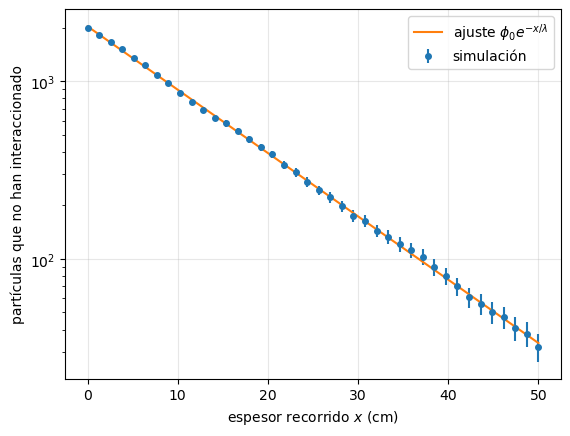

In [5]:
sim.atenuacion(n=2000, lambda_real=12., espesor=50.);

### Vida media

Otro de los observables principales en Física Nuclear y de Partículas es el tiempo de
desintegración. Antes de escribir ninguna fórmula, miremos lo que se mide.

Preparamos una muestra grande de muones, que se desintegran según $\mu \to e + \bar{\nu}_e + \nu_\mu$, y
vamos contando cuántos quedan. Al cabo de un intervalo $T$ se ha desintegrado la mitad.

**¿Y en el siguiente intervalo $T$? ¿Se acaban?** Opina antes de ejecutar la siguiente celda.


 muestra inicial  N = 20000
 vida media       tau =  2.197
 semidesintegración T = tau ln2 =  1.523

          quedan   N/2^k
  t = 1T     9989   10000.0
  t = 2T     4958    5000.0
  t = 3T     2551    2500.0
  t = 4T     1277    1250.0
  t = 5T      619     625.0


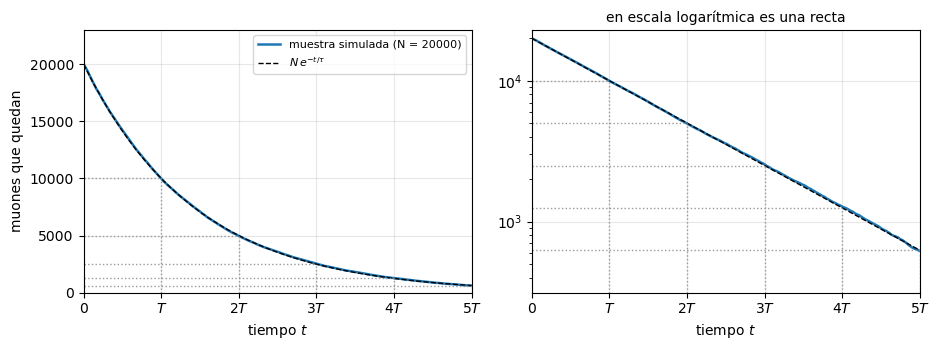

In [ ]:
sim.supervivientes(n=20000, tau_real=2.197);
# el panel de la derecha está en escala logarítmica: ln N(t) es una recta de pendiente -1/tau_real


#### Lo que se observa

No se acaban. En el segundo intervalo se desintegra la mitad **de los que quedaban**; en
el tercero, la mitad de ésos; y así indefinidamente. La muestra no pierde cantidades
iguales, se reduce por **factores iguales**.

Llamemos $S(t) = N(t)/N(0)$ a la probabilidad de **sobrevivir** hasta $t$. Lo que cumplen
los datos, para dos intervalos cualesquiera, es

$$
S(t_1 + t_2) = S(t_1) \, S(t_2)
$$

sobrevivir un rato y luego otro más es el producto de las dos supervivencias.

**¿Qué ley diferencial sigue entonces la desintegración de $N$ partículas?**


#### La ley de desintegración

Basta leer esa identidad para un intervalo pequeño. La probabilidad de que una partícula se desintegre en
$\mathrm{d}t$ es siempre la misma, y la escribimos

$$
\mathrm{d}p = \frac{\mathrm{d}t}{\tau}
$$

donde la constante $\tau$ tiene dimensiones de tiempo. La probabilidad de sobrevivir ese
$\mathrm{d}t$ es $S(\mathrm{d}t) = 1 - \mathrm{d}t/\tau$, y entonces

$$
S(t + \mathrm{d}t) = S(t) \, S(\mathrm{d}t)
= S(t) \left( 1 - \frac{\mathrm{d}t}{\tau} \right)
\; \to \;
\frac{\mathrm{d}S}{\mathrm{d}t} = - \frac{S}{\tau}
$$

Con $N$ partículas independientes, $N(t) = N(0) \, S(t)$, es la misma ecuación. El signo
es negativo porque las que se desintegran salen de la muestra:

$$
\frac{\mathrm{d}N}{\mathrm{d}t} = - \frac{N}{\tau}
\; \to \;
N(t) = N(0) \, e^{-t/\tau}
$$

que es la curva que acabamos de contar, $2^{-t/T}$, escrita en base $e$. A la constante
$\tau$ la llamamos **tiempo de vida media**.

<details>
<summary><b>¿Y si el intervalo no es pequeño?</b></summary>

$\mathrm{d}p = \mathrm{d}t/\tau$ solo vale mientras la probabilidad sea pequeña: si en 1 s
vale $10^{-3}$, extrapolar linealmente a $10^4$ s daría 10, que no es una probabilidad. Un
intervalo finito se construye componiendo muchos intervalos pequeños, y eso es justo lo
que hace integrar la ecuación.

</details>


#### La vida media es la media de los tiempos

El nombre no es casual: $\tau$ es literalmente el tiempo que vive en promedio una
partícula. El tiempo de desintegración de una partícula se distribuye con la densidad de
probabilidad $f(t) = \frac{1}{\tau} e^{-t/\tau}$ —la $\mathrm{d}N/\mathrm{d}t$ de la ley,
cambiada de signo y normalizada a una partícula—, y de ahí obtenemos su promedio:

$$
\langle t \rangle = \frac{1}{\tau} \int_0^\infty t \; e^{-t/\tau} \, \mathrm{d}t = \tau
$$

Es decir, la vida media. Es además el tiempo en el que la muestra se reduce a $1/e \simeq 37 \, \%$. Y medir una
vida media es, sencillamente, **promediar los tiempos de desintegración** que registra el
detector.

Por ejemplo, el neutrón se desintegra $n \to p + e + \bar{\nu}_e$ con $\tau = 878.4$ s,
unos 15 minutos. Y el muón, $\mu \to e + \nu_\mu + \bar{\nu}_e$, tiene $\tau = 2.197\ \mu$s.


<div class="admonition tip">
<p class="admonition-title"><b>[>] Taller — Mide una vida media</b></p>

Simula la desintegración de una muestra de muones ($\tau = 2.197\ \mu$s) y mide $\tau$
a partir de los datos, sin mirar el valor de entrada.

1. Ejecuta la primera celda. ¿A cuántas desviaciones típicas queda el valor medido
   del real? Vuelve a ejecutarla: la semilla es aleatoria, así que es **otra toma de
   datos** y sale otro número. ¿Cuántas veces de diez esperas quedarte a más de 1 σ?
2. La segunda celda acumula sucesos: el histograma de $n=100$ contiene los 10
   anteriores, y así hasta $10^4$. **¿A partir de cuántos sucesos reconoces la forma
   exponencial?** ¿Y a partir de cuántos dirías que la medida es fiable?
3. **¿Cómo escala el error con el número de sucesos?** Si quisieras mejorar tu medida
   un factor 10, ¿cuánto tendrías que aumentar la estadística?

</div>

 tau de entrada = 2.1970
 tau medida     = 2.3497 +- 0.1661   (0.9 sigmas de la de entrada, con n = 200)


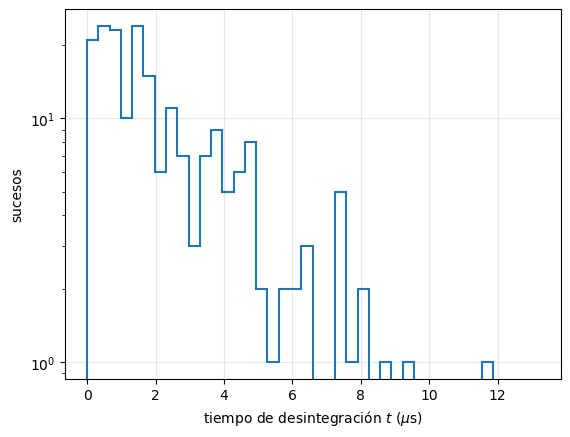

In [3]:
sim.vida_media(n=200, tau_real=2.197);

 tau de entrada = 2.1970
   n =      10  ->  tau = 1.9337 +- 0.6115   (0.4 sigmas)
   n =     100  ->  tau = 2.4757 +- 0.2476   (1.1 sigmas)
   n =    1000  ->  tau = 2.2989 +- 0.0727   (1.4 sigmas)
   n =   10000  ->  tau = 2.2016 +- 0.0220   (0.2 sigmas)


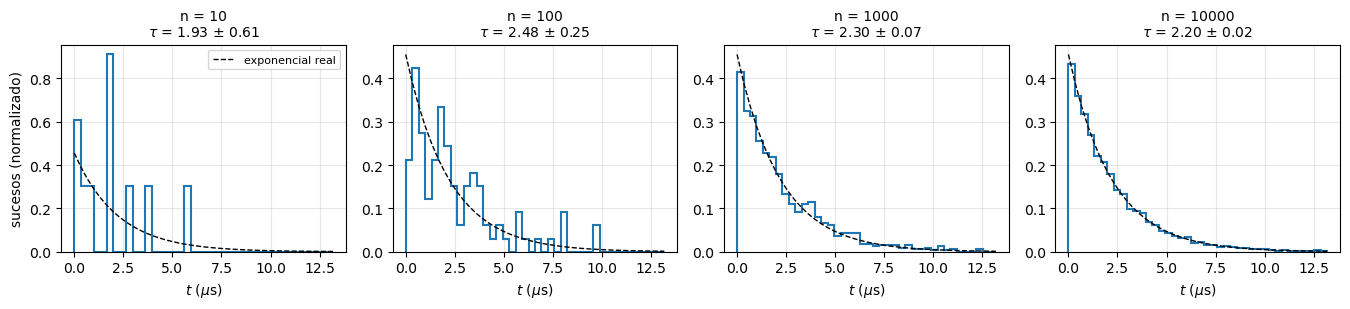

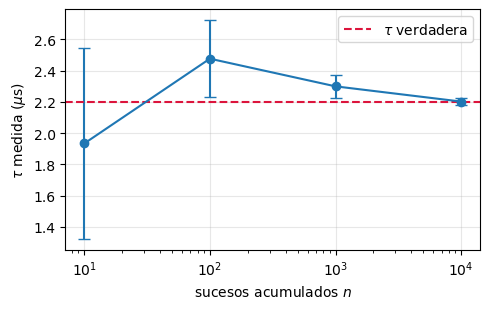

In [4]:
sim.vida_media_evolucion(ns=(10, 100, 1000, 10000), tau_real=2.197);

# En clase: descomenta la línea siguiente para verlo como animación.
# Ojo: no guardes el notebook con su salida (~1.5 MB por animación).
# sim.vida_media_animada(n_max=10000, tau_real=2.197)

<details>
<summary><b>Solución de la pregunta 3</b></summary>

El error escala como $1/\sqrt{n}$: concretamente $\sigma_\tau = \tau/\sqrt{n}$. Se ve
en los títulos de los cuatro histogramas y, sobre todo, en la segunda figura: cada
salto de un factor 100 en $n$ divide la barra de error por 10.

Para ganar un factor 10 en precisión hay que multiplicar por **100** el número de sucesos.
Esta ley es la que gobierna el coste de casi todo experimento de partículas: la
precisión es cara, y cada dígito significativo nuevo cuesta cien veces más datos que
el anterior.

</details>

<div class="admonition note">
<p class="admonition-title"><b>[i] Vida media y periodo de semidesintegración</b></p>

Son dos tiempos distintos y conviene no mezclarlos:

| | | |
|:--|:--:|:--|
| **vida media** | $\tau$ | la vida promedio; la muestra cae a $1/e \simeq 37\,\%$ |
| **periodo de semidesintegración**, o **semivida** | $t_{1/2}$ | la muestra cae a la mitad |

Imponiendo $N(t_{1/2}) = N(0)/2$ en la ley exponencial:

$$
t_{1/2} = \tau \, \ln 2 \simeq 0.693 \, \tau
\qquad
\tau = \frac{t_{1/2}}{\ln 2} \simeq 1.443 \, t_{1/2}
$$

La semivida es siempre **menor** que la vida media. Para el neutrón, $\tau = 878.4$ s
corresponde a $t_{1/2} = 609$ s.

En inglés son *mean lifetime* ($\tau$) y *half-life* ($t_{1/2}$); *half-life* se traduce
mal a menudo por "vida media". Las tablas de isótopos de Física Nuclear suelen dar
$t_{1/2}$, mientras que el PDG da $\tau$: al comparar números, mira siempre cuál de los
dos es.

En Física Nuclear esta misma constante se escribe $\lambda$ y se llama **constante de
desintegración**; con ella, la **actividad** de una muestra es $A = \lambda N = N/\tau$,
el número de desintegraciones por segundo (en becquerel).

</div>


#### Las partículas no envejecen

Volvamos a la identidad que cumplían los datos, $S(t_1 + t_2) = S(t_1) \, S(t_2)$. Tiene
nombre: es la **falta de memoria**. Dicho con la muestra, de los que siguen vivos en
$t_0$ sobrevive otro rato $t$ la misma fracción que en una muestra recién preparada:

$$
\frac{N(t_0 + t)}{N(t_0)} = \frac{e^{-(t_0+t)/\tau}}{e^{-t_0/\tau}} = e^{-t/\tau} = S(t)
$$

**El $t_0$ desaparece.** A un muón que lleva $10 \, \mu$s sin desintegrarse le quedan por
delante los mismos $2.2 \, \mu$s de media que a uno recién creado. No está *gastado*, ni
le *toca ya*. Y la implicación va en los dos sentidos: la exponencial es **la única**
función monótona que cumple esa identidad.

Compáralo con lo que sí envejece: que una persona de 20 años llegue a los 21 no tiene la
misma probabilidad que una de 90 llegue a los 91, y una bombilla encendida acumula
desgaste en el filamento. Ahí el pasado **sí** cuenta, y la distribución de vidas no es
exponencial.


<div class="admonition tip">
<p class="admonition-title"><b>[>] Taller — ¿Le toca ya?</b></p>

Un muón lleva $3\tau$ sin desintegrarse. **Antes de ejecutar nada**, responde:

1. ¿Cuánto tiempo le queda de vida, en promedio? ¿Menos de $\tau$, $\tau$, o más de $\tau$?
2. De una muestra inicial de $200\,000$ muones, ¿cuántos siguen vivos en $t = 3\tau$?
3. Ejecuta la celda. El panel izquierdo son partículas reales; el derecho, una población
   inventada que **sí** envejece, con la misma vida media. ¿En qué se distinguen los
   histogramas?
4. ¿Cómo comprobarías experimentalmente cuál de los dos comportamientos tiene un isótopo
   radiactivo real?

</div>

 vida media de entrada = 2.1970

 sin memoria (exponencial)
   muestra recién preparada     n =  200000   les quedan 2.2019 +- 0.0049
   sobrevivieron a t > 1 tau    n =   73575   les quedan 2.2127 +- 0.0082
   sobrevivieron a t > 3 tau    n =   10147   les quedan 2.1765 +- 0.0216

 que envejece (Weibull k=3)
   muestra recién preparada     n =  200000   les quedan 2.1970 +- 0.0049
   sobrevivieron a t > 1 tau    n =   98265   les quedan 0.6575 +- 0.0021
   sobrevivieron a t > 3 tau    n =       0   no sobrevive ninguna



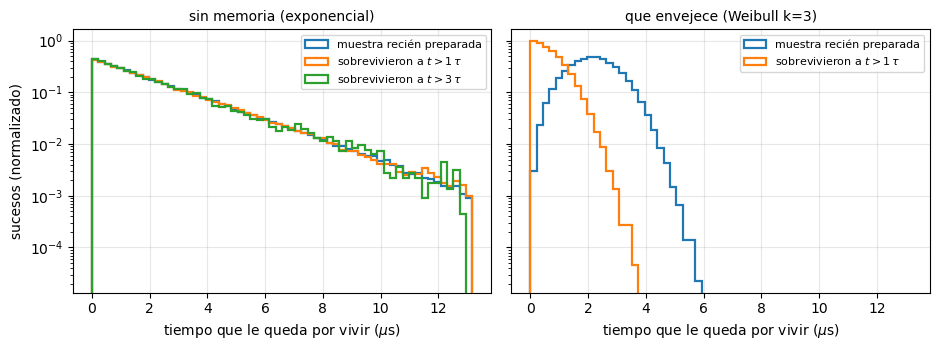

In [5]:
sim.vida_media_sin_memoria(n=200000);

<details>
<summary><b>Solución</b></summary>

1. **Exactamente $\tau$**, los mismos $2.2 \, \mu$s que al nacer. Es lo que más cuesta
   aceptar: haber sobrevivido no es información sobre el futuro. La respuesta intuitiva
   —"le queda menos, que ya ha vivido mucho"— es la falacia del jugador.
2. $200\,000 \, e^{-3} \approx 10\,000$, un 5 %.
3. A la izquierda **los tres histogramas caen uno encima de otro**: la distribución del
   tiempo restante no depende de la edad. A la derecha se separan y se corren hacia la
   izquierda: tras una vida media, a los supervivientes ya solo les quedan $0.66 \,\mu$s
   en vez de $2.2$, y a $3\tau$ no queda ninguno.
   Mira también cuántos sobreviven a $1\tau$: un 37 % en el caso exponencial frente a un
   49 % en el que envejece. La población que envejece muere **de golpe**, en torno a su
   edad típica; la que no tiene memoria muere siempre al mismo ritmo.
4. Midiendo $\tau$ en una muestra recién preparada y volviendo a medirla en la misma
   muestra mucho después. Si la partícula envejeciera, $\tau$ crecería o menguaría con la
   edad de la muestra. No lo hace: por eso funciona la datación radiométrica, y por eso
   es consistente entre isótopos de vidas medias muy distintas.

</details>

#### La vida media depende del observador

Volvamos a $\tau$. Todo lo anterior —la ley exponencial, la falta de memoria— vale en el
sistema en que la partícula está **en reposo**. Esa $\tau_0$ es su *vida media propia*, y
es la que aparece en las tablas del PDG.

Pero el tiempo depende del observador. En el laboratorio la partícula va a velocidad
$\beta$, sus relojes van dilatados, y la vida media que medimos es

$$
\tau = \gamma \, \tau_0 = \frac{E}{m} \, \tau_0 \; \geq \; \tau_0
$$

Y lo que un detector observa no es un tiempo, sino una **distancia**: cuánto vuela la
partícula antes de desintegrarse. Es la **longitud de desintegración**

$$
L = v \, \tau = \beta c \, \gamma \tau_0 = \gamma\beta \; c \tau_0
= \frac{\mathrm{p}}{m c} \, c\tau_0
$$

Notar que aquí la longitud está en el SI (al reponer $c$). ¿Cómo queda en unidades
naturales?

Las dos expresiones se comportan de forma muy distinta, y merece la pena verlo:

| | |
|:--|:--|
| $\tau(\mathrm{p})$ | tiene **meseta** en $\tau_0$ mientras $\mathrm{p} \ll mc$, y crece linealmente después |
| $L(\mathrm{p})$ | es **exactamente proporcional** a $\mathrm{p}$, sin meseta, para cualquier partícula |

Para el muón, $\tau_0 = 2.197\ \mu$s y $c\tau_0 = 659$ m.


 muón cósmico típico:  p = 4 GeV
   gamma =   37.9,  beta = 0.999651
   vida media en el laboratorio  =     83.2 us   (en reposo, 2.20 us)
   longitud de desintegración    =     24.9 km   (sin dilatación, 0.659 km)


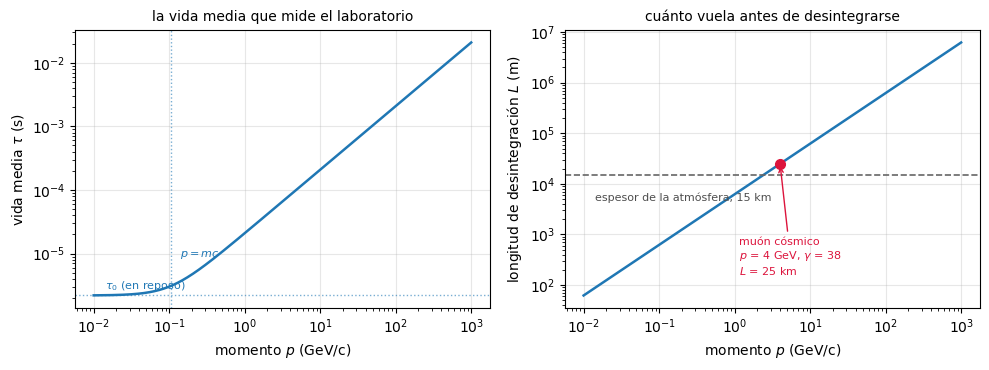

In [6]:
t1.plot_dilatacion_temporal();


<div class="admonition tip">
<p class="admonition-title"><b>[>] Taller — ¿Por qué nos llegan los muones?</b></p>

Los muones cósmicos se producen al chocar los protones del espacio con la alta atmósfera,
a unos **15 km** de altura, y se detectan de sobra a nivel del mar. Con
$\tau_0 = 2.197\ \mu$s y $m_\mu c^2 = 105.7$ MeV:

1. Si **no** hubiera dilatación temporal, ¿cuánto recorrería un muón en una vida media?
   Compáralo con los 15 km.
2. Un muón cósmico típico llega con $p = 4$ GeV/c. Calcula $\gamma$, la vida media que
   mide el laboratorio y la longitud de desintegración $L$.
3. Con $S = e^{-d/L}$, ¿qué fracción sobrevive a los 15 km en cada caso? ¿Cuál es
   la razón entre las dos?
4. Mira la figura: **¿por qué el panel de la izquierda tiene un codo y el de la derecha
   no?**

</div>


<details>
<summary><b>Solución</b></summary>

1. $c\tau_0 = 659$ m, y a $\beta \simeq 1$ eso es lo que recorre. Los 15 km son **23
   longitudes de desintegración**: no llegaría prácticamente ninguno.
2. $E = \sqrt{p^2c^2 + m^2c^4} = 4001$ MeV, así que $\gamma = E/mc^2 = 37.9$ y
   $\beta = 0.99965$. La vida media en el laboratorio es $\tau = \gamma\tau_0 =
   83\ \mu$s —frente a los $2.2\ \mu$s en reposo— y
   $L = \gamma\beta\, c\tau_0 = 24.9$ km.
3. Sin dilatación, $S = e^{-15000/659} = e^{-22.8} = 1.3 \times 10^{-10}$.
   Con dilatación, $S = e^{-15000/24900} = e^{-0.60} = 0.55$.
   La razón es de **$4 \times 10^9$**: la mitad de los muones llega frente a
   prácticamente ninguno. Los muones que nos atraviesan ahora mismo son la evidencia
   directa de la dilatación temporal — es el experimento de **Rossi y Hall (1941)**,
   que comparó el flujo de muones a distintas altitudes.
4. Porque en $L = \beta c \cdot \gamma\tau_0$ los dos factores se compensan
   **exactamente**. A momento bajo, $\gamma \to 1$ (no hay dilatación, $\tau \to \tau_0$:
   ahí está la meseta del panel izquierdo) pero también $\beta \to 0$, y la partícula no
   recorre nada. A momento alto, $\beta \to 1$ se satura pero $\gamma$ crece sin límite.
   El producto $\gamma\beta = p/mc$ es lineal en $p$ en todo el rango, y por eso
   $L$ no tiene codo.

</details>


### El invariante $s$

En cualquier proceso, sea una desintegración o una colisión, se conserva el cuadrimomento
total:

$$
\sum_{\mathrm{iniciales}} p_i = \sum_{\mathrm{finales}} p_j
$$

Si dos cuadrimomentos son iguales, también lo son sus normas, y la norma de un cuadrivector
es invariante. Tiene nombre propio:

$$
s = \Big( \sum_{\mathrm{iniciales}} p_i \Big)^2 = \Big( \sum_{\mathrm{finales}} p_j \Big)^2
$$

Es la primera de las **variables de Mandelstam**, que veremos en el tema de cinemática.
Como $s$ es invariante y se conserva, se puede calcular con las partículas iniciales o con
las finales, y en el sistema de referencia que más convenga.

¿Qué significa? Depende de cuántas partículas haya en el estado inicial:

| estado inicial | $\sqrt{s}$ es |
|:--|:--|
| **una** partícula, $a \to 1 + 2 + \dots$ | su masa, $m_a$ |
| **dos** partículas, $a + b \to c + d + \dots$ | la energía disponible en el centro de masas |

#### Una partícula inicial: la masa invariante

Hemos visto *cuándo* se desintegra una partícula. Pero de una partícula de vida corta el
detector solo ve los productos. ¿Cómo sabemos de dónde vienen?

En la desintegración $a \to 1 + 2 + \dots + n$ el estado inicial es una sola partícula, y
la norma de su cuadrimomento es, por la ecuación de Einstein, su masa:

$$
s = p_a^2 = m_a^2 = \Big( \sum_i p_i \Big)^2
= \Big( \sum_i E_i \Big)^2 - \Big| \sum_i {\bf p}_i \Big|^2
$$

Midiendo las energías y los momentos de los productos en el laboratorio,
**reconstruimos la masa de la madre**, se moviera como se moviera.

La expresión de la derecha se puede calcular con cualquier conjunto de partículas. La
llamamos **masa invariante** del sistema, $M$, y todos los observadores miden la misma. Si
las partículas vienen de la desintegración de $a$, $M = m_a$ siempre; si no, $M$ toma un
valor cualquiera.

En el sistema en reposo del conjunto, $M = \sum_i E_i \geq \sum_i m_i$, y la diferencia
es el valor $Q$ de la desintegración.

#### El pico del $B^0_s$

La figura es la masa invariante de los pares $\mu^+\mu$ seleccionados por LHCb en el
Run 1 ($3\ \mathrm{fb^{-1}}$, izquierda) y en el Run 2 ($6\ \mathrm{fb^{-1}}$, derecha).

| |
|:--:|
|<img src="./imgs/intro_massinv_Bsmumu.png" width = 700 align="center">|
| Masa invariante $m_{\mu^+\mu}$ en los datos de LHCb, Run 1 (izda) y Run 2 (dcha) [[LHCb](https://doi.org/10.1103/PhysRevD.105.012010)]|

* El pico en $m_{\mu\mu} \simeq 5367$ MeV es la masa del mesón $B^0_s = (s\bar{b})$: son
  desintegraciones $B^0_s \to \mu^+ + \mu$ (en rojo).
* El pequeño pico verde, en $5280$ MeV, sería el $B^0$, que en estos datos no llega a ser
  significativo.
* El resto es **fondo**: pares de muones que no vienen de la misma partícula, o
  desintegraciones parecidas en las que alguna partícula se pierde o se confunde con un
  muón.

Con el doble de luminosidad integrada, el pico del Run 2 destaca mucho más sobre el fondo.

<div class="admonition tip">
<p class="admonition-title"><b>[>] Taller — Reconstruye un $B^0_s$</b></p>

En un suceso de LHCb se miden dos muones ($m_\mu = 105.7$ MeV) con momentos, en GeV,

$$
{\bf p}_{\mu^+} = (1.20,\; 0.40,\; 15.00), \qquad
{\bf p}_{\mu} = (-1.45,\; -3.55,\; 10.00)
$$

1. Calcula la masa invariante del par. ¿Es un candidato a $B^0_s$?
2. El $B^0_s$ tiene $\tau = 1.52$ ps. Con el momento de este suceso, ¿cuánto vuela en
   promedio antes de desintegrarse? ¿Se puede ver el vértice desplazado?
3. Si combinas el $\mu^+$ de este suceso con un $\mu$ de *otro* suceso, ¿qué masa
   invariante esperas? ¿De dónde sale entonces el fondo de la figura, y qué harías para
   reducirlo?

</div>

<details>
<summary><b>Solución</b></summary>

1. $E_{\mu^+} = 15.054$ GeV y $E_{\mu} = 10.711$ GeV, así que $\sum E = 25.764$ GeV.
   $\sum {\bf p} = (-0.25,\; -3.15,\; 25.00)$ GeV, con $|\sum {\bf p}|^2 = 634.99\
   \mathrm{GeV^2}$. Entonces $M^2 = 25.764^2 - 634.99 = 28.81\ \mathrm{GeV^2}$ y
   $M = 5.367$ GeV: **sí**, coincide con $m_{B^0_s}$.
   Fíjate en que cada muón tiene $E \gg m_\mu$ y aun así el par pesa 5.4 GeV: la masa
   invariante no es la suma de las masas, la pone sobre todo el **ángulo** entre ellos.
2. $\mathrm{p} = |\sum {\bf p}| = 25.2$ GeV, luego $\gamma\beta = \mathrm{p}/m = 4.7$.
   Con $c\tau = 456\ \mu$m, $L = \gamma\beta \, c\tau \approx 2.1$ mm. Sí: los detectores
   de silicio de LHCb resuelven vértices a decenas de micras.
3. Dos muones de sucesos distintos no tienen ninguna relación, y su masa invariante sale
   con cualquier valor: da una distribución continua, sin pico. Es el **fondo
   combinatorio**. Se reduce exigiendo lo que la pregunta 2 dice que tiene la señal: que
   los dos muones salgan de un mismo vértice, desplazado milímetros del punto de colisión.

</details>

#### Dos partículas iniciales: la energía en el centro de masas

En una colisión, $a + b \to c + d + \dots$, el estado inicial son dos partículas. La norma
del cuadrimomento total, $s = (p_a + p_b)^2$, ya no es la masa de nadie, pero sigue siendo
invariante.

En el CM, ${\bf p}_a + {\bf p}_b = {\bf 0}$, y $s = (E_a + E_b)^2$, con las energías medidas en el CM: $\sqrt{s}$ es la
**energía total disponible en el centro de masas**, la del eje de la figura de OPAL.

Fíjate en que el $\sqrt{s}$ de cada toma de datos aparece en la figura de luminosidad de
ATLAS: 7 y 8 TeV en el Run 1, 13 TeV en el Run 2 y 13.6 TeV en el Run 3. En el Run 3
cada haz lleva protones de 6.8 TeV, y $\sqrt{s} = 2 \times 6.8 = 13.6$ TeV.

<div class="admonition tip">
<p class="admonition-title"><b>[>] Taller — $s$ en el sistema del laboratorio</b></p>

Como $s$ es invariante, se puede calcular en el sistema que más convenga. En un
experimento de **blanco fijo**, una partícula $a$ de masa $m_a$, energía $E_a$ y momento
${\bf p}_a$ incide sobre una partícula $b$ de masa $m_b$ **en reposo**.

1. Escribe los cuadrimomentos $p_a$ y $p_b$ en el laboratorio, y calcula
   $s = (p_a + p_b)^2$. *Ayuda:* $E_a^2 - \mathrm{p}_a^2 = m_a^2$.
2. ¿Cómo queda $\sqrt{s}$ cuando $E_a \gg m_a, m_b$?
3. Haz lo mismo en un **colisionador simétrico**: dos haces de energía $E$ con momentos
   opuestos. ¿Cómo crece $\sqrt{s}$ con la energía del haz en cada caso?
4. Un haz de protones de 6.8 TeV contra un blanco de hidrógeno, ¿qué $\sqrt{s}$ alcanza?
   Compáralo con los 13.6 TeV del LHC.

</div>

<details>
<summary><b>Solución</b></summary>

1. En el laboratorio, $p_a = (E_a, {\bf p}_a)$ y $p_b = (m_b, {\bf 0})$. Entonces
   $p_a + p_b = (E_a + m_b, \; {\bf p}_a)$ y

$$
s = (E_a + m_b)^2 - \mathrm{p}_a^2
  = \underbrace{E_a^2 - \mathrm{p}_a^2}_{m_a^2} + 2 m_b E_a + m_b^2
  = m_a^2 + m_b^2 + 2 \, m_b \, E_a
$$

2. Si $E_a \gg m_a, m_b$, domina el último término: $s \simeq 2 m_b E_a$ y
   $\sqrt{s} \simeq \sqrt{2 m_b E_a}$.
3. Con $p_1 = (E, {\bf p})$ y $p_2 = (E, -{\bf p})$, $p_1 + p_2 = (2E, {\bf 0})$ y
   $s = (2E)^2$: $\sqrt{s} = 2E$. En el colisionador $\sqrt{s}$ crece **linealmente** con
   la energía del haz; en blanco fijo, solo como su **raíz cuadrada**.
4. $s = 2 m_p^2 + 2 m_p E = 2 \times 0.938^2 + 2 \times 0.938 \times 6800 \approx
   1.28 \cdot 10^4\ \mathrm{GeV^2}$, así que $\sqrt{s} \approx 113$ GeV: **120 veces
   menos** que los 13.6 TeV que el LHC consigue con esos mismos protones enfrentados.

</details>

#### Colisionador y blanco fijo

Resumiendo, con $E \gg m$:


| | $s$ | $\sqrt{s}$ |
|:--|:--|:--|
| colisionador simétrico, haces de energía $E$ | $(2E)^2$ | $2E$ |
| blanco fijo, $b$ en reposo | $m_a^2 + m_b^2 + 2 m_b E_a$ | $\simeq \sqrt{2 m_b E_a}$ |

En blanco fijo la energía disponible crece solo como la raíz: para ganar un factor 10 en
$\sqrt{s}$ hay que multiplicar por 100 la energía del haz. Por eso las energías más altas se alcanzan en colisionadores: igualar los 13.6 TeV del
LHC con un blanco fijo de protones exigiría un haz de
$E_a \simeq s/2m_p \approx 10^8$ GeV $= 10^{17}$ eV, una energía que solo alcanzan
algunos rayos cósmicos.

#### La energía umbral

Una reacción con $Q < 0$ necesita energía. La mínima es la que crea las partículas finales
en reposo en el CM, y entonces

$$
s_{\mathrm{min}} = \Big( \sum_{\mathrm{finales}} m_j \Big)^2
$$

Igualándolo con el $s$ calculado en el laboratorio sale la energía cinética umbral del
haz, $T_a = E_a - m_a$. Dedúcela en el taller siguiente.

<div class="admonition tip">
<p class="admonition-title"><b>[>] Taller — Deduce la energía umbral</b></p>

La reacción $a + b \to 1 + 2 + \dots + n$ tiene $Q = m_a + m_b - M < 0$, donde
$M = \sum_j m_j$ es la suma de las masas finales. El blanco $b$ está en reposo.

1. ¿Por qué la energía mínima es la que deja las partículas finales en reposo **en el
   CM**? ¿Cuánto vale entonces $s$?
2. Iguala ese $s_{\mathrm{min}}$ con el $s$ que calculaste en el laboratorio en el taller
   anterior, y despeja $E_a$.
3. Escribe la energía cinética, $T_a = E_a - m_a$, en función de $|Q|$.
   *Ayuda:* busca una diferencia de cuadrados.
4. ¿Por qué el resultado es siempre **mayor** que $|Q|$?

</div>

<details>
<summary><b>Solución</b></summary>

1. En el CM el momento total es nulo, así que $\sqrt{s} = \sum_j E^*_j \geq \sum_j m_j = M$,
   con la igualdad solo si todas las partículas finales están en reposo en el CM. Cualquier
   energía cinética en el CM exigiría más $\sqrt{s}$. Y como en el laboratorio $s$ crece
   con $E_a$, la mínima $s$ es la mínima energía del haz:
   $s_{\mathrm{min}} = M^2$.
2. Con el resultado del taller anterior:

$$
m_a^2 + m_b^2 + 2 \, m_b \, E_a = M^2
\quad \Longrightarrow \quad
E_a^{\mathrm{umbral}} = \frac{M^2 - m_a^2 - m_b^2}{2 \, m_b}
$$

3. Restando $m_a = 2 m_a m_b / 2 m_b$, el numerador se completa en un cuadrado:

$$
T_a^{\mathrm{umbral}} = \frac{M^2 - (m_a + m_b)^2}{2 \, m_b}
= \frac{(M - m_a - m_b)(M + m_a + m_b)}{2 \, m_b}
= |Q| \; \frac{M + m_a + m_b}{2 \, m_b}
$$

   porque $M - m_a - m_b = -Q = |Q|$.
4. Como $Q < 0$, $M > m_a + m_b$, y entonces $M + m_a + m_b > 2(m_a + m_b) \geq 2 m_b$:
   el factor que multiplica a $|Q|$ es siempre mayor que 1. En el laboratorio el
   proyectil trae momento, el sistema final tiene que llevárselo, y esa energía cinética
   no está disponible para crear masa.

</details>

Resumiendo, en blanco fijo la energía cinética umbral del haz es

$$
T_a^{\mathrm{umbral}} = |Q| \; \frac{\sum_j m_j + m_a + m_b}{2 \, m_b} \; > \; |Q|
$$

En el CM basta con $|Q|$, pero en el laboratorio hace falta **más**: el CM se mueve, y por
conservación del momento las partículas finales tienen que llevarse energía cinética.

<div class="admonition tip">
<p class="admonition-title"><b>[>] Taller — ¿Cuánta energía hace falta?</b></p>

Masas (en MeV): $m_p = 938.272$, $m_n = 939.565$, $m_e = 0.511$, $m_\nu \approx 0$.

1. **Detectar un antineutrino.** Los antineutrinos de un reactor se detectan con la
   desintegración $\beta$ inversa sobre los protones del agua, $\bar{\nu}_e + p \to n + e^+$.
   ¿Cuál es su $Q$? ¿Qué energía mínima necesita el $\bar{\nu}_e$? Compárala con $|Q|$.
2. **Crear un antiprotón.** $p + p \to p + p + p + \bar{p}$, con un haz de protones
   contra un blanco de hidrógeno. ¿Cuál es su $Q$? ¿Qué energía cinética mínima necesita el
   haz? ¿Cuántas veces $|Q|$?
3. ¿Y si la misma reacción se hace en un **colisionador** simétrico? ¿Qué energía cinética
   necesita cada haz? ¿Por qué no coinciden las respuestas 2 y 3, y por qué en la 1 casi
   coinciden?

</div>

<details>
<summary><b>Solución</b></summary>

1. $Q = m_p - m_n - m_e = -1.804$ MeV: es la $Q$ del taller del neutrón, cambiada de signo.
   Con $m_a = 0$ y $m_b = m_p$,
   $E_\nu^{\mathrm{umbral}} = 1.804 \times (939.565 + 0.511 + 938.272)/(2 \times 938.272)
   = 1.806$ MeV, prácticamente $|Q|$. O directamente, igualando
   $s = m_p^2 + 2 m_p E_\nu = (m_n + m_e)^2$:
   $E_\nu = [(m_n + m_e)^2 - m_p^2]/(2 m_p)$.
   Los antineutrinos de reactor llegan hasta unos 8 MeV, así que una parte supera el umbral.
   Así los detectaron por primera vez Reines y Cowan, en 1956.
2. $Q = 2m_p - 4m_p = -2m_p = -1.876$ GeV. Con $\sum_j m_j = 4m_p$ y $m_a = m_b = m_p$,
   $T^{\mathrm{umbral}} = 2m_p \times 6m_p / 2m_p = 6 \, m_p = 5.63$ GeV: **tres veces**
   $|Q|$. El Bevatron de Berkeley se diseñó con 6.2 GeV justamente para esto, y con él
   Chamberlain y Segrè descubrieron el antiprotón en 1955.
3. En un colisionador simétrico el CM es el laboratorio. Basta con que cada protón lleve
   $E = 2m_p$, es decir, $T = m_p = 0.938$ GeV por haz: $|Q|$ en total, sin desperdicio.
   En blanco fijo el sistema final se mueve, y esa energía cinética se pierde para crear
   masa. Cuánta se pierde depende de lo ligero que sea el proyectil frente al blanco. En
   la 1, un neutrino sin masa contra un protón apenas mueve el CM; en la 2, proyectil y
   blanco pesan lo mismo, y se pierden dos tercios.

</details>

### Fracción de desintegración

El muón y el tauón son copias del electrón con más masa, y los dos se desintegran por la
interacción débil. Pero no de la misma manera:

| | se desintegra en | |
|:--|:--|:--|
| $\mu$ ($m = 105.7$ MeV) | $e + \bar{\nu}_e + \nu_\mu$ | prácticamente **siempre** |
| $\tau$ ($m = 1777$ MeV) | $e + \bar{\nu}_e + \nu_\tau$, $\;\mu + \bar{\nu}_\mu + \nu_\tau$, $\;$hadrones $+  \nu_\tau$ | **unas veces uno, otras otro** |

Cada modo de desintegración es un **canal**.

**Antes de seguir, mójate:**

1. ¿Por qué el muón tiene un solo canal y el tauón varios? *Pista:* piensa en el valor $Q$.
2. Preparas muchos $\tau$. ¿Qué número usarías para decir cómo se reparten entre sus
   canales? ¿Un porcentaje? Y si es un porcentaje, **¿de qué?**

#### La fracción de desintegración

1. **Por el valor $Q$.** Un muón solo puede desintegrarse en partículas más ligeras que él
   que conserven la carga y los números leptónicos: un electrón y neutrinos. El hadrón más
   ligero, el pión ($m_\pi \simeq 140$ MeV), ya pesa más que el muón. El tauón, con
   1777 MeV, tiene sitio para un muón y para varios piones.

2. **Un porcentaje, sí: de las desintegraciones.** No es un porcentaje de las partículas
   producidas ni del tiempo: de todas las que se desintegran, qué fracción lo hace por cada
   canal. Es la **fracción de desintegración** (*branching ratio*) del canal $i$:

$$
\mathcal{Br}_i = \frac{N_i}{N}, \qquad \sum_i \mathcal{Br}_i = 1
$$

Para el muón, $\mathcal{Br}(\mu \to e + \bar{\nu}_e + \nu_\mu) \simeq 100 \, \%$. (En rigor,
a veces el electrón sale acompañado de un fotón, pero es el mismo proceso con radiación.)
Para el tauón [PDG]:

| canal | $\tau \to e + \bar{\nu}_e + \nu_\tau$ | $\tau \to \mu + \bar{\nu}_\mu + \nu_\tau$ | $\tau \to \mathrm{hadrones} + \nu_\tau$ |
|:--|:--:|:--:|:--:|
| $\mathcal{Br}$ | 17.8 % | 17.4 % | 64.8 % |

Fíjate en que $e$ y $\mu$ salen casi con la misma fracción: es la **universalidad**
leptónica, con una pequeña diferencia por la masa del muón.

#### Canales raros

Las fracciones van desde casi 1 hasta valores minúsculos. Volvamos al pico del $B^0_s$: son
**unas decenas** de sucesos, cuando LHCb produce del orden de $10^{11}$ mesones $B^0_s$.
¿Por qué tan pocos? Porque es uno de los canales más raros que se han medido [PDG]:

$$
\mathcal{Br}(B^0_s \to \mu^+ + \mu) = (3.3 \pm 0.3) \cdot 10^{-9}
$$

uno de cada 300 millones. Y es justamente lo que lo hace interesante: el Modelo Estándar
lo predice con precisión, y una partícula nueva que contribuyera a la desintegración lo
cambiaría.

#### Anchura de desintegración

¿Cómo encaja esto con la ley de desintegración? La probabilidad de desintegrarse en
$\mathrm{d}t$ era $\mathrm{d}t/\tau$. La de hacerlo **por el canal $i$** es una fracción
$\mathcal{Br}_i$ de ella, y la escribimos

$$
\mathrm{d}p_i = \frac{\mathcal{Br}_i}{\tau} \, \mathrm{d}t \equiv \Gamma_i \, \mathrm{d}t
$$

Los canales son excluyentes, así que sus probabilidades **se suman**:

$$
\Gamma \equiv \sum_i \Gamma_i = \frac{1}{\tau},
\qquad
\mathcal{Br}_i = \frac{\Gamma_i}{\Gamma}
$$

$\Gamma_i$ es la **anchura parcial** del canal $i$, y $\Gamma$, la **anchura de
desintegración** (total). En unidades naturales el inverso de un tiempo es una energía, y
$\Gamma$ se da en MeV. Al reponer $\hbar$:

$$
\Gamma = \frac{\hbar}{\tau}, \qquad \hbar = 6.58 \cdot 10^{-22}\ \mathrm{MeV\,s}
$$

Una consecuencia, y una pregunta:

* **Se suman los ritmos, no los tiempos.** Abrir un canal nuevo aumenta $\Gamma$ y
  *acorta* la vida media de la partícula, también para los canales que ya había.
* **¿Tiene cada canal su propia vida media?** En el $\tau$, $\Gamma_e$ es casi cuatro
  veces menor que $\Gamma_{\mathrm{had}}$. ¿Tardan más en desintegrarse los $\tau$ que
  lo hacen en electrón? Mójate, y compruébalo en el taller siguiente.

La teoría calcula las $\Gamma_i$, que dependen del acoplo de la interacción y del espacio
fásico. El experimento mide $\tau$ y las $\mathcal{Br}_i$.

<div class="admonition tip">
<p class="admonition-title"><b>[>] Taller — ¿Tarda más el canal raro?</b></p>

El $\tau$ se desintegra en hadrones un 65 % de las veces, y en electrón o en muón un
18 %. **Antes de ejecutar nada**, responde:

1. Los $\tau$ que se desintegran en $e + \bar{\nu}_e + \nu_\tau$, ¿viven en promedio más,
   menos o lo mismo que los que se desintegran en hadrones?
2. Entre los $\tau$ que se desintegran en la primera décima de vida media, ¿qué fracción
   lo hace en hadrones? ¿Y entre los que duran más de $3\tau$?
3. Ejecuta la celda. La simulación le da a cada $\tau$ **un despertador por canal**, que
   suena en un instante al azar con ritmo $\Gamma_i$ (el del canal raro suele sonar más
   tarde). El $\tau$ se desintegra cuando suena **el primero**, y por el canal de ese
   despertador. A la derecha, un mundo inventado en el que el $\tau$ elige canal al nacer
   y vive la vida media *propia* de ese canal, $1/\Gamma_i$. ¿En qué se distinguen
   los dos mundos, arriba y abajo?
4. Si $B^0_s \to \mu^+ + \mu$ tuviera su propia vida media, $\tau_{B_s}/\mathcal{Br}$, con
   $\tau_{B_s} = 1.52$ ps, ¿cuánto volaría con el $\gamma\beta \simeq 4.7$ del suceso que
   reconstruiste? LHCb ve sus vértices a milímetros del punto de colisión. ¿Qué concluyes?

</div>

In [ ]:
sim.canales(n=200000);

<details>
<summary><b>Solución</b></summary>

1. **Lo mismo.** Los tres canales tienen $\langle t \rangle = 0.290$ ps, la vida media del
   $\tau$. Si el canal a electrón tuviera vida propia, sería $1/\Gamma_e = 1.6$ ps, y no la
   tiene.
2. **El 65 % en los dos casos.** Las fracciones no dependen de cuándo se mire.
3. **Real, arriba:** las tres distribuciones son rectas **paralelas** en escala
   logarítmica, con la misma pendiente, $-1/\tau$, y alturas proporcionales a
   $\mathcal{Br}_i$. **Real, abajo:** la fracción de cada canal es plana.
   **Inventado:** las pendientes son distintas, los hadrones dominan al principio y los
   leptones al final. Y ni siquiera se conserva la vida media total, que sale $3\tau$.

   Un ejemplo: si a un $\tau$ le salen $t_e = 1.3$ ps, $t_\mu = 0.9$ ps y
   $t_{\mathrm{had}} = 0.2$ ps, se desintegra a los 0.2 ps y en hadrones; los otros dos
   despertadores nunca llegan a sonar. El del canal raro suena de media más tarde, pero
   cuando gana es porque ha sonado pronto.

   La razón de fondo es la carrera: el instante en que suena el *primero* de varios
   despertadores exponenciales es otra exponencial, con ritmo $\sum_i \Gamma_i = \Gamma$, y **no depende
   de cuál gane**. Escrito como ecuación, los productos del canal $i$ aparecen a ritmo

$$
\frac{\mathrm{d}N_i}{\mathrm{d}t} = \Gamma_i \, N(t) = \Gamma_i \, N_0 \, e^{-\Gamma t}
$$

   la misma exponencial para todos, con distinta normalización. Por eso abrir un canal
   nuevo acorta la vida de **todos**: el despertador nuevo también puede ganar.
4. $\tau_{B_s}/\mathcal{Br} = 1.52 \cdot 10^{-12} / 3.3 \cdot 10^{-9} \approx 5 \cdot
   10^{-4}$ s, así que $c\tau \approx 140$ km y $L = \gamma\beta \, c\tau \approx 650$ km.
   LHCb los ve a milímetros, como los demás canales del $B^0_s$: el canal raro no tarda
   más, simplemente ocurre menos.

   (Un matiz para quien lo busque: el $B^0_s$ es mezcla de dos estados con vidas medias
   algo distintas, y LHCb mide para $B^0_s \to \mu^+ + \mu$ una vida media *efectiva* de
   unos 2 ps. Son picosegundos, no milisegundos; pero por eso el ejemplo limpio es el
   $\tau$.)

</details>

#### ¿Por qué *anchura*?

Volvamos al pico de OPAL. El $Z$ tiene $\Gamma_Z = 2.4955$ GeV [PDG], así que vive

$$
\tau_Z = \frac{\hbar}{\Gamma_Z}
= \frac{6.58 \cdot 10^{-25}\ \mathrm{GeV\,s}}{2.50\ \mathrm{GeV}}
\simeq 2.6 \cdot 10^{-25}\ \mathrm{s}
$$

Una partícula que vive tan poco no tiene una energía en reposo bien definida. Por la
relación de incertidumbre, $\Delta E \, \Delta t \sim \hbar$, su masa está repartida en un
intervalo $\Delta E \sim \hbar/\tau = \Gamma$. Por eso el $Z$ no se produce solo a
$\sqrt{s} = m_Z$, sino en un intervalo de energías en torno a ella. La sección eficaz tiene
la forma de una curva de **Breit–Wigner**,

$$
\sigma(\sqrt{s}) \propto \frac{\Gamma_Z^2/4}{(\sqrt{s} - m_Z)^2 + \Gamma_Z^2/4}
$$

cuya anchura total a media altura es, justamente, $\Gamma_Z$. De ahí el nombre. (La
asimetría del pico de OPAL se debe a que los electrones radian fotones antes de chocar, y
llegan con algo menos de energía.)

| |
|:--:|
| <img src="./imgs/intro_Zreso_OPAL.png" width = 300 align="center">|
| Ajuste de OPAL: $m_Z = 91.185$ GeV, $\Gamma_Z = 2.495$ GeV [OPAL]|

Una vida media se mide, por tanto, de dos maneras según lo que dure la partícula:

| vida media | se mide por | ejemplos |
|:--|:--|:--|
| $\tau \gtrsim 10^{-13}$ s | la **longitud de vuelo**, $L = \gamma\beta \, c\tau$: el vértice desplazado | $\mu$, $\tau$, $B^0_s$ |
| $\tau \lesssim 10^{-22}$ s ($\Gamma \gtrsim$ MeV) | la **anchura** del pico, en la masa invariante o en $\sigma(\sqrt{s})$ | $Z$, $W$, resonancias fuertes |

Entre medias ni se ve el vuelo ni se resuelve la anchura, y hacen falta métodos indirectos:
así se mide, por ejemplo, la del $\pi^0$, $8.5 \cdot 10^{-17}$ s.

<div class="admonition tip">
<p class="admonition-title"><b>[>] Taller — Del $B^0_s$ al número de neutrinos</b></p>

1. **¿Por qué tan pocos $B^0_s$?** En el Run 2 de LHCb ($6\ \mathrm{fb^{-1}}$) la sección
   eficaz de producción de pares $b\bar{b}$ es $\sigma_{b\bar{b}} \simeq 500\ \mu$b, y en
   un $\sim 20 \, \%$ de los pares se forma un $B^0_s$ (o su antipartícula). ¿Cuántas
   desintegraciones $B^0_s \to \mu^+ + \mu$ se produjeron? Compáralo con el pico de la
   figura. ¿Qué te dice eso de la eficiencia?
2. **El $\tau$.** Con $\tau_\tau = 2.903 \cdot 10^{-13}$ s y la tabla de fracciones,
   calcula $\Gamma_\tau$ y las anchuras parciales a $e$ y a $\mu$, en eV. ¿Podrías medir
   la vida media del $\tau$ por la anchura de un pico?
3. **El $Z$.** ¿Cuánto recorre un $Z$ producido en LEP antes de desintegrarse? Compáralo
   con el radio del protón.
4. **¿Cuántos neutrinos?** Restando a $\Gamma_Z$ las anchuras parciales a hadrones y a
   leptones cargados, que sí se ven, queda la anchura a lo que el detector *no* ve:
   $\Gamma_{\mathrm{inv}} = 499.0 \pm 1.5$ MeV. El Modelo Estándar predice
   $\Gamma(Z \to \nu + \bar{\nu}) = 167.2$ MeV por cada tipo de neutrino. ¿Cuántos tipos hay?

</div>

<details>
<summary><b>Solución</b></summary>

1. $500\ \mu\mathrm{b} = 5 \cdot 10^{11}$ fb, así que se producen
   $5 \cdot 10^{11} \times 6 \approx 3 \cdot 10^{12}$ pares $b\bar{b}$ y
   $\sim 6 \cdot 10^{11}$ mesones $B^0_s$. Por $\mathcal{Br} = 3.3 \cdot 10^{-9}$,
   **unas 2000** desintegraciones $B^0_s \to \mu^+ + \mu$. En la figura se cuentan unas
   decenas: la eficiencia total es del orden del 1–2 %. Se pierde en la aceptación (LHCb
   solo cubre la región hacia delante), en el disparo y en una selección que, para quitarse
   el fondo, sacrifica señal.
   Por eso la fracción medida no sale de esta cuenta, sino de comparar con un canal de
   $\mathcal{Br}$ conocido, en el que buena parte de estas incertidumbres se cancelan.
2. $\Gamma_\tau = \hbar/\tau = 6.58 \cdot 10^{-16}\ \mathrm{eV\,s} / 2.903 \cdot
   10^{-13}\ \mathrm{s} = 2.3 \cdot 10^{-3}$ eV, y
   $\Gamma_e = 0.178 \, \Gamma_\tau = 4.0 \cdot 10^{-4}$ eV,
   $\Gamma_\mu = 0.174 \, \Gamma_\tau = 3.9 \cdot 10^{-4}$ eV.
   **No.** La resolución en masa de un detector es del orden del MeV, $10^9$ veces mayor.
   El $\tau$ vive mucho: se mide por el vuelo, con $c\tau = 87\ \mu$m.
3. $c\tau_Z = \hbar c / \Gamma_Z = 0.197\ \mathrm{GeV\,fm} / 2.50\ \mathrm{GeV}
   \approx 0.08$ fm. Y en LEP los haces son simétricos, así que el $Z$ se produce en reposo
   y ni siquiera eso: no vuela. Es diez veces menos que el radio del protón, $0.84$ fm.
   Su vida media solo es accesible a través de la anchura.
4. $N_\nu = 499.0 / 167.2 = 2.98 \approx 3$. Cada tipo adicional de neutrino con masa
   menor que $m_Z/2$ añadiría 167 MeV a la anchura invisible, y no está. Esta es la medida
   que, desde 1989, fija en **tres** las familias con neutrino ligero. Volveremos a ella
   al hablar de las generaciones del Modelo Estándar.

</details>

## Radiación $\alpha, \beta, \gamma$

### De los griegos clásicos a nuestros días

En el *De rerum natura* de [Lucrecio](https://es.wikipedia.org/wiki/Lucrecio) (siglo I a.C.), el poeta romano, inspirado por Epicuro y en última instancia por Demócrito, expone su visión de la Naturaleza: 

_todo lo que existe está hecho de átomos y vacío_.

En nuestra visión contemporánea: el mundo está constituido por partículas fundamentales y por vacío.

También argumenta que:

_"Haud igitur redit ad nihilum res ulla, sed omnes
dissoluuntur et in res cunctas remeare videntur."_

(Ninguna cosa vuelve a la nada: todas se disuelven y parecen regresar a otros cuerpos.)

En nuestra versión moderna: La energía ni se crea ni se destruye, se conserva. Las partículas se transforman unas en otras.

$$
E = m \, c^2
$$

En la actualidad, nuestro conocimiento de los componentes fundamentales de la Naturaleza está contenido en el _Modelo Estándar_.

Clasificar y comprender las interacciones de las partículas es una tarea comunitaria que dura desde finales del siglo XIX, se inicia con el descubrimiento del electrón, y llega hasta nuestros días, siendo el último gran descubrimiento el del bosón de Higgs en 2012.

No obstante, la imagen que surge del Modelo Estándar, aunque poco intuitiva, es relativamente simple.

### La tabla periódica

Clasificar nos permite desvelar la estructura interna subyacente.

Mendeleev (1869) clasifica por propiedades los átomos y Moseley (1913) los ordena por Z.

| |
|:--:|
| <img src="./imgs/gen_tabla_periodica.png" width = 700 align="center">|
| Tabla periódica de los elementos [[Wikipedia]](https://es.wikipedia.org/wiki/Tabla_peri%C3%B3dica_de_los_elementos)|



La tabla periódica supone una ordenación de los elementos:
- Disposición por **número atómico** (Z).
- **Periodos** (filas) y **grupos** (columnas).
- Bloques electrónicos: **s, p, d, f**.

### Radiaciones α, β, γ

A finales del siglo XIX y principios del XX se descubrieron distintos tipos de radiaciones, cuyos nombres aún se utilizan: $\alpha, \beta, \gamma$, y que corresponden respectivamente a las interacciones fuerte, débil y electromagnética.

Estas radiaciones tienen un rango típico de energía de MeV.



### Radiación $\alpha$

La radiación nuclear la descubrió (accidentalmente) Becquerel (1896) y la estudió en detalle Marie Curie.

Henri Becquerel, físico francés, estaba estudiando la fluorescencia de sales de uranio.
Creía que, al exponerse al sol, éstas emitirían rayos X.

Un día nublado, sin sol, guardó sus placas fotográficas envueltas junto con el uranio.
Cuando las reveló, vio que estaban veladas.

«Les sels d’uranium émettent spontanément des rayonnements capables d’impressionner une plaque photographique à travers un papier opaque.» (H. Becquerel)

El uranio emitía una radiación invisible, espontánea, sin necesidad de excitación externa.
Eso fue el nacimiento del concepto de radiactividad natural.

Actualmente el becquerel (Bq) se usa como unidad para indicar desintegraciones por segundo.


Posteriormente [Marie Skłodowska Curie](https://en.wikipedia.org/wiki/Marie_Curie) y su marido Pierre Curie descubrieron dos nuevos elementos mucho más radiactivos que el uranio: el polonio y el radio.

Marie acuñó el término «radiactividad».

En esta desintegración del uranio se emite una radiación $\alpha$, es decir, un núcleo de helio (con $Z = 2$):

$$
{}^{238}_{92}\mathrm{U} \rightarrow {}^{234}_{90}\mathrm{Th} + {}^{4}_{2}\mathrm{He}
$$

La radiación $\alpha$ es poco penetrante.


### Radiación $\beta$

Un núcleo emite una radiación más penetrante que la $\alpha$. En 1899 Rutherford la
distingue de aquella por su poder de penetración y la llama $\beta$; poco después,
Becquerel (1900) y Kaufmann miden su relación carga/masa y la identifican: **son
electrones**.

Con eso, la reacción parece resuelta. Por ejemplo:

$$
{}^{14}_{6}\mathrm{C} \;\rightarrow\; {}^{14}_{7}\mathrm{N} \;+\; e
$$

El núcleo hijo es miles de veces más pesado que el electrón y su retroceso es
despreciable, así que **la conservación de la energía fija la energía del electrón**:
todos deberían salir con la misma, $T_e \simeq Q$. El espectro debería ser **una raya**.

En 1914 James Chadwick lo mide con cuidado, y encuentra otra cosa: el espectro es
**continuo**. Los electrones salen con todas las energías, desde cero hasta un valor
máximo — y ese máximo coincide justo con la $Q$ esperada.

No es un detalle técnico: es una contradicción con la conservación de la energía, medida
en el laboratorio. El problema se queda sin resolver dieciséis años.

*(Nota histórica: el neutrón no se descubre hasta 1932. En 1914 todo esto se escribía a
nivel de núcleos; que por debajo hay un $n \to p$ vino después.)*

<div class="admonition tip">
<p class="admonition-title"><b>[>] Taller — Deduce tú lo que falta (1/2)</b></p>

Este es *el* experimento del capítulo. Estás en 1914 y sabes esto y nada más:

* la radiación $\beta$ son electrones;
* si la desintegración fuera a **dos cuerpos**, todos saldrían con la misma energía;
* el espectro medido es **continuo**, y su extremo superior está en la $Q$ esperada.

1. ¿Qué explicaciones se te ocurren para un espectro continuo? Haz tu lista **antes** de
   seguir: hubo tres sobre la mesa, y las tres se defendieron.
2. Si decides que en el estado final hay una partícula más, ¿qué **carga eléctrica**
   tiene?
3. El neutrón, el protón y el electrón tienen espín $1/2$. Aparte de la energía, ¿qué
   otro problema tiene $n \to p + e$? ¿Qué espín debe tener entonces lo que falta?
4. ¿Por qué no la había visto nadie?

</div>


<div class="admonition tip">
<p class="admonition-title"><b>[>] Taller — Deduce tú lo que falta (2/2)</b></p>

Ejecuta la celda de abajo, que compara los espectros a dos y a tres cuerpos. Usa
$Q = 0.782$ MeV, la del neutrón, que será nuestro caso de referencia; el argumento es
idéntico para el ${}^{14}$C.

5. Si hay una partícula invisible llevándose energía, ¿por qué el extremo del espectro
   sigue cayendo exactamente en $Q$?
6. Mira ese extremo. Si la partícula que falta tuviera masa, ¿cómo cambiaría esa zona?
   ¿Se te ocurre cómo medir esa masa?

</div>


 2 cuerpos: una raya en T = 0.782 MeV
 3 cuerpos: continuo entre 0 y Q = 0.782 MeV


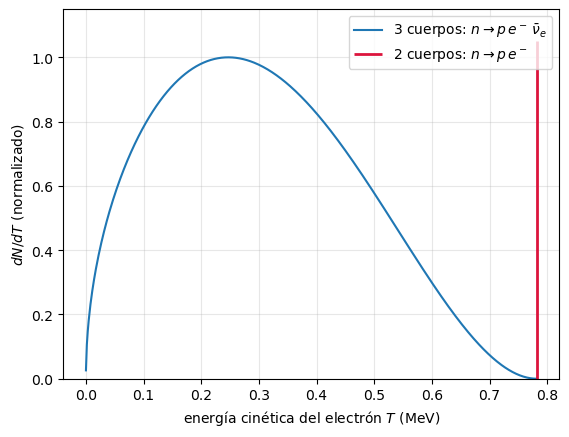

In [5]:
sim.espectro_beta(Q=0.782);

<details>
<summary><b>Solución</b></summary>

1. Tres opciones, y ninguna era descabellada entonces:
   * **la energía no se conserva** en los procesos nucleares — la defendió Bohr;
   * **el experimento está mal** — se descartó al repetirlo con calorímetros;
   * **falta algo** en el estado final que se lleva la energía que no vemos.

   Pauli eligió la tercera en 1930, en una carta que empieza *"Queridas señoras y señores
   radiactivos"* y en la que la llama "un remedio desesperado".

2. **Neutra.** La carga ya está equilibrada entre ${}^{14}$C y ${}^{14}$N $+\, e$, así que
   lo que falta no puede llevarla.

3. **El momento angular.** $n \to p + e$ sería $1/2 \to 1/2 + 1/2$: de semientero a
   entero, imposible. Hace falta un tercer cuerpo de espín semientero, y el más simple es
   $1/2$. Este argumento es **independiente** del de la energía y por sí solo ya exige una
   partícula nueva: aunque renunciaras a la conservación de la energía, el espín seguiría
   sin cuadrar. Por eso la opción de Bohr no salvaba nada.

4. Porque es neutra y su sección eficaz es minúscula: atraviesa el detector, el
   laboratorio y la Tierra entera sin dejar rastro. Pasaron 26 años hasta que Cowan y
   Reines la detectaron, en 1956, junto a un reactor nuclear.

5. Porque entre todos los repartos posibles de energía hay uno en el que la partícula
   invisible se lleva prácticamente nada: ése es el electrón más energético. Que el
   extremo caiga justo en $Q$ es, de hecho, **la prueba de que la energía sí se conserva**.

6. Si tuviera masa $m$, no podría crearse con menos energía que $m$, así que al electrón
   nunca le quedarían disponibles los últimos $m$: el espectro se cortaría en $Q - m$ y la
   forma de los últimos electrones cambiaría. **Medir con precisión ese extremo es
   exactamente como se mide hoy la masa del neutrino** (experimento KATRIN, con tritio). La
   dificultad es que solo una fracción minúscula de los electrones cae en esa región.

Fíjate en el método, porque es el del oficio: una **discrepancia en la forma de un
espectro** obligó a postular una partícula nueva, y **dos leyes de conservación distintas**
—energía y momento angular— apuntaban a lo mismo. Es el razonamiento con el que hoy se
busca física más allá del Modelo Estándar.

</details>


Así que en el estado final hay una cuarta partícula: neutra, ligerísima, de espín $1/2$ y
casi imposible de detectar. Pauli la postuló en 1930; Fermi la bautizó **neutrino** y en
1934 construyó con ella la primera teoría de la desintegración $\beta$; Cowan y Reines la
detectaron en 1956.

Escrita completa, la desintegración es

$$
{}^{14}_{6}\mathrm{C} \;\rightarrow\; {}^{14}_{7}\mathrm{N} \;+\; e \;+\; \bar{\nu}_e
\qquad \text{y, por debajo,} \qquad
n \;\rightarrow\; p \;+\; e \;+\; \bar{\nu}_e
$$

Esta última será nuestra guía para entender las desintegraciones débiles. La historia del
neutrino merece su lugar aparte, y la contaremos en otra ocasión.

### Radiación $\gamma$

Finalmente, algunos núcleos emiten fotones de alta energía, penetrantes, que se denominan rayos $\gamma$.

Como es el caso del Cobalto:

$$
{}^{60}_{27}\mathrm{Co} \;\xrightarrow{\beta}\; {}^{60}_{28}\mathrm{Ni}^* + e + \bar{\nu}_e \;\xrightarrow{\gamma}\; {}^{60}_{28}\mathrm{Ni} + 2\gamma
$$

donde el ${}^{60}\mathrm{Ni}^*$ se desexcita emitiendo dos fotones, de 1.17 y 1.33 MeV.

Paul Villard, en 1900, estudiando la radiación del radio, observa un componente extremadamente penetrante que no se desvía en un campo magnético. En 1903 Rutherford lo identifica como un tercer tipo de radiación, que bautiza como rayos $\gamma$, y establece que no son partículas cargadas (como $\alpha$ o $\beta$), sino radiación electromagnética de alta energía.



Más adelante utilizaremos los diagramas de niveles para indicar las desintegraciones:

| |
|:--:|
| <img src="./imgs/gen_Co60_decay.png" width = 300 align="center">|
| Diagrama de desintegración del ${}^{60}\mathrm{Co}$ [Wikipedia] |

Puedes explorar [aquí](https://www-nds.iaea.org/relnsd/vcharthtml/VChartHTML.html) otros diagramas de niveles

<div class="admonition tip">
<p class="admonition-title"><b>[>] Taller — Juega con la carta de núclidos</b></p>

La [carta de núclidos de la IAEA](https://www-nds.iaea.org/relnsd/vcharthtml/VChartHTML.html)
contiene todo lo que se sabe de todos los núcleos conocidos. Ábrela y busca:

1. El ${}^{60}\mathrm{Co}$: ¿cuál es su periodo de semidesintegración? ¿Y las energías
   de los dos fotones que emite el ${}^{60}\mathrm{Ni}^*$?
2. El ${}^{14}\mathrm{C}$: ¿por qué sirve para datar restos arqueológicos y no, digamos,
   fósiles de dinosaurios?
3. Localiza el "valle de estabilidad". ¿Por qué los núcleos pesados estables necesitan
   más neutrones que protones?

</div>

<details>
<summary><b>Pistas</b></summary>

1. $T_{1/2} \approx 5.27$ años; los fotones son de 1.17 y 1.33 MeV.
2. $T_{1/2}({}^{14}\mathrm{C}) \approx 5700$ años. Tras unos 10 periodos (≈ 60 000 años)
   no queda actividad medible; un dinosaurio de 65 millones de años está fuera de rango
   por tres órdenes de magnitud.
3. La repulsión coulombiana entre protones crece como $Z^2$, mientras que la fuerza
   fuerte es de corto alcance y solo liga a los vecinos. Añadir neutrones aporta
   atracción fuerte sin añadir repulsión eléctrica.

</details>

### Interacciones electromagnética, débil y fuerte

Recordemos que la energía típica de las radiaciones nucleares $\alpha, \beta, \gamma$ es del MeV.

La radiación $\gamma$ es _electromagnética_, tiene referente clásico.

La desintegración $\beta$ es _débil_, tiene un rango muy pequeño, $10^{-3}$ fm (fm = $10^{-15}$ m), y aparece por primera vez en las reacciones nucleares. Su tratamiento es cuántico.

La desintegración $\alpha$ es una manifestación de la interacción _fuerte_, la responsable de la existencia del núcleo, entre otros fenómenos, y su alcance es del fm. De nuevo su tratamiento es cuántico.

En Física Nuclear haremos un tratamiento cuántico y -en general- no relativista, mientras que en Física de Partículas, el tratamiento es cuántico y -casi siempre- relativista.

## De los núcleos a los quarks

### Dispersión del núcleo

En 1909, H. Geiger y E. Marsden estudiaban la dispersión de partículas alfa en una lámina de oro, y E. Rutherford sugerió estudiar si existían dispersiones a altos ángulos.

| | 
|:--:| 
| <img src="./imgs/gen_alphaexp_diagram.png" width = 240 align="center">|
| Esquema de dispersión [Geiger, Marsden]|



Rutherford: “It was quite the most incredible event that has ever happened to me in my
life. It was almost as incredible as if you fired a 15-inch shell at a piece of
tissue paper and it came back and hit you.” 

Rutherford concluyó, entre otras cosas, que la mayor
parte de la masa y la carga positiva del átomo se concentran en una región
extremadamente pequeña, a lo que se denominó núcleo.

| | 
|:--:| 
| <img src="./imgs/gen_alpha_dispersion_diagram.png" width = 500 align="center"> |
| Trayectoria hiperbólica de la partícula $\alpha$ [Rutherford]|



Rutherford describió la dispersión de las partículas alfa a través de la interacción
electromagnética. Asumiendo que el núcleo no tenía retroceso e ignorando la interacción
con los electrones, la situación es matemáticamente la misma que las soluciones de Kepler
a las órbitas planetarias: la partícula alfa recorre una hipérbola. Él la resolvió por esa
vía; en el taller siguiente llegamos al mismo sitio sin tocar la órbita.

$$
\frac{d\sigma}{d\Omega} \;=\;
\left( \frac{1}{4\pi \varepsilon_0} \,
\frac{Z_1 Z_2 e^2}{4E} \right)^{\!2}
\frac{1}{\sin^4\!\left(\tfrac{\theta}{2}\right)}
$$

| |
|:--:|
| <img src="./imgs/gen_alphadisp_parabol.png" width = 240 align="center"> |
| La figura original del artículo de Rutherford (1911): la hipérbola completa, con las asíntotas y el ángulo de dispersión $\theta$. |


<div class="admonition tip">
<p class="admonition-title"><b>[>] Taller — Deduce la sección eficaz de Rutherford</b></p>

Acabamos de escribir la fórmula; ahora dedúcela. Sale entera de la figura de arriba,
**sin resolver la órbita**: hacen falta las dos leyes de conservación, un argumento de
simetría y algo de geometría.

Trabaja en el límite de Rutherford: núcleo fijo (sin retroceso), colisión elástica,
$E = \frac{1}{2} m v_0^2$ la energía cinética de la $\alpha$, y $\theta$ el ángulo de
dispersión (la figura lo llama $\vartheta$).

1. **El triángulo de la derecha.** ¿Cuánto vale $|\Delta {\bf p}|$ en función del momento
   $p$ y del ángulo $\theta$?

   <details>
   <summary><i>Pista</i></summary>

   Si la colisión es elástica y el núcleo no retrocede, $|{\bf p}_i| = |{\bf p}_f| = p = m v_0$:
   el triángulo es **isósceles**. Pártelo por la bisectriz.

   </details>

2. **El impulso.** $\Delta {\bf p} = \int {\bf F} \, \mathrm{d}t$. ¿Qué componente de
   ${\bf F}$ sobrevive a la integral y cuál se cancela?

   <details>
   <summary><i>Pista</i></summary>

   La trayectoria es **simétrica** respecto de la bisectriz del ángulo de dispersión.
   Mira qué le pasa a cada componente al pasar de la mitad de entrada a la de salida.

   </details>

3. **La integral.** Cambia la variable de integración de $t$ a $\varphi$. **¿Qué le
   ocurre entonces al $1/r^2$ de la ley de Coulomb?**

   <details>
   <summary><i>Pista</i></summary>

   Aquí entra la segunda ley de conservación: el **momento angular** respecto del núcleo,
   $L = m v_0 b = m r^2 \dot\varphi$. Despeja $\mathrm{d}t$ de ahí y sustituye.

   </details>

4. **Los límites.** Midiendo $\varphi$ desde la bisectriz, ¿entre qué dos valores hay que
   integrar?

   <details>
   <summary><i>Pista</i></summary>

   La $\alpha$ viene del infinito y se va al infinito, así que los límites los fijan las
   **asíntotas**. Mide en la figura el ángulo que forman con la bisectriz.

   </details>

5. **El final.** Iguala 1 con 4, despeja el **parámetro de impacto** $b(\theta)$ y llega
   a la sección eficaz.

   <details>
   <summary><i>Pista</i></summary>

   $$
   \frac{d\sigma}{d\Omega} = \frac{b}{\sin\theta} \left| \frac{db}{d\theta} \right|
   $$

   y $\sin\theta = 2 \sin\frac{\theta}{2} \cos\frac{\theta}{2}$ lo simplifica todo.

   </details>

</div>


<details>
<summary><b>Solución</b></summary>

**1.** El triángulo es isósceles, con ángulo $\theta$ entre los dos lados iguales.
Partiéndolo por la bisectriz:

$$
|\Delta {\bf p}| = 2 \, p \, \sin \frac{\theta}{2} = 2 \, m v_0 \sin\frac{\theta}{2}
$$

**2.** La componente de ${\bf F}$ perpendicular a la bisectriz cambia de signo entre la
mitad de entrada y la de salida: su integral se anula. Solo sobrevive la componente
*a lo largo* de la bisectriz, que es la dirección de $\Delta {\bf p}$:

$$
|\Delta {\bf p}| = \int F \cos\varphi \; \mathrm{d}t,
\qquad F = \frac{1}{4\pi\varepsilon_0} \frac{Z_1 Z_2 e^2}{r^2}
$$

**3.** De $L = m v_0 b = m r^2 \dot\varphi$ sale
$\mathrm{d}t = \frac{r^2}{v_0 b} \, \mathrm{d}\varphi$. Al sustituir, **el $r^2$ del
jacobiano cancela exactamente el $1/r^2$ de Coulomb**:

$$
|\Delta {\bf p}| = \frac{1}{4\pi\varepsilon_0} \frac{Z_1 Z_2 e^2}{v_0 \, b}
\int \cos\varphi \; \mathrm{d}\varphi
$$

Esto es lo que hace elemental el problema: la integral ya no depende de la trayectoria.

**4.** Las asíntotas forman un ángulo $(\pi - \theta)/2$ con la bisectriz, luego

$$
\int_{-(\pi-\theta)/2}^{+(\pi-\theta)/2} \cos\varphi \; \mathrm{d}\varphi
= 2 \sin\frac{\pi-\theta}{2} = 2 \cos\frac{\theta}{2}
$$

**5.** Igualando con el paso 1 y usando $E = \frac{1}{2} m v_0^2$:

$$
b = \frac{1}{4\pi\varepsilon_0} \, \frac{Z_1 Z_2 e^2}{2E} \, \cot\frac{\theta}{2}
$$

Derivando, $\left|\frac{db}{d\theta}\right| = \frac{1}{2} \frac{1}{4\pi\varepsilon_0}
\frac{Z_1 Z_2 e^2}{2E} \, \frac{1}{\sin^2(\theta/2)}$, y con
$\sin\theta = 2 \sin\frac{\theta}{2}\cos\frac{\theta}{2}$ todo se simplifica a

$$
\frac{d\sigma}{d\Omega} = \left( \frac{1}{4\pi\varepsilon_0} \,
\frac{Z_1 Z_2 e^2}{4E} \right)^{\!2} \frac{1}{\sin^4(\theta/2)}
$$

**Dos observaciones.** La primera: no es *solo* conservación. Hacen falta las dos leyes
(pasos 1 y 3) **más** la simetría del paso 2 y la geometría del paso 4 — pero en ningún
momento hay que resolver la ecuación de la órbita. La segunda: la divergencia en
$\theta \to 0$ es real y viene del alcance infinito de Coulomb; en un átomo la apantallan
los electrones, que aquí hemos ignorado.

</details>


### Dispersión de Mott

Mott estudió la dispersión de electrones de alta energía en los núcleos; para ello hay que tener en cuenta el espín del electrón y la mecánica cuántica relativista.

$$
\frac{d\sigma}{d\Omega} \;=\;
\frac{Z^2 \alpha^2}{4 E^2 \, \sin^4\!\left(\tfrac{\theta}{2}\right)}
\;\Big[ 1 - \beta^2 \sin^2\!\left(\tfrac{\theta}{2}\right) \Big]
$$

Y si consideramos el retroceso del núcleo:

$$
\frac{d\sigma}{d\Omega} \;=\;
\frac{Z^2 \alpha^2}{4 E^2 \, \sin^4\!\left(\tfrac{\theta}{2}\right)}
\; \frac{E'}{E} \;
\Big[ 1 - \beta^2 \sin^2\!\left(\tfrac{\theta}{2}\right) \Big]
\qquad \text{con} \qquad
E' = \frac{E}{1 + \frac{2 E}{M} \sin^2(\theta/2)}
$$

donde:
- $Z$: número atómico del núcleo
- $\alpha = e^2 / 4 \pi \varepsilon_0 \hbar c \simeq 1/137$: la constante de estructura fina
- $E$: energía total del electrón incidente
- $E'$: energía del electrón dispersado
- $M$: masa del núcleo
- $\theta$: ángulo de dispersión en el laboratorio
- $\beta$: velocidad del electrón incidente en unidades de $c$

Aquí ya usamos **unidades naturales**, $c = 1$: por eso $E$, $M$ y las masas van en las mismas unidades, y $\varepsilon_0$ y $e$ quedan absorbidos en $\alpha$. Para pasar la sección eficaz a fm$^2$ se repone $\hbar c = 197$ MeV fm.

Frente a Rutherford aparecen dos factores nuevos: $E'/E$, el retroceso del núcleo, y $1 - \beta^2 \sin^2(\theta/2)$, el efecto del espín del electrón, que suprime la retrodispersión.

<div class="admonition tip">
<p class="admonition-title"><b>[>] Taller — El proyectil de 15 pulgadas</b></p>

Rutherford dijo que ver rebotar una $\alpha$ fue *"casi tan increíble como disparar un
obús de 15 pulgadas contra un papel de seda y que volviera y te golpease"*. Vamos a ver
por qué le sorprendió tanto.

La simulación enfrenta dos modelos del átomo con $\alpha$ de 5 MeV sobre oro:

* **Thomson**: la carga positiva repartida por todo el átomo. Muchas desviaciones
  minúsculas que se acumulan.
* **Rutherford**: toda la carga concentrada en un núcleo puntual.

1. ¿Qué fracción de partículas se dispersa a más de 90° en cada modelo?
2. ¿Por qué el modelo de Thomson da **exactamente cero** y no simplemente "muy poco"?
3. La lámina de Geiger y Marsden tenía $\sim 4 \cdot 10^{-5}$ cm de oro
   ($\rho = 19.3$ g/cm³, $A = 197$). Estima con lápiz y papel la fracción de
   $\alpha$ que retrodispersan y compárala con el "1 de cada 8000" que midieron.

</div>

<details>
<summary><b>Pistas para la pregunta 3</b></summary>

La cuenta es una sección eficaz en su forma más desnuda: **cuántos blancos ve el
proyectil** $\times$ **qué área ofrece cada blanco**.

* **Cuántos blancos.** La densidad superficial de núcleos, $n_A = \rho \, N_A \, t / A$,
  en núcleos/cm². Sigue las unidades: $\rho t$ es g/cm², dividir por $A$ da mol/cm², y
  multiplicar por $N_A$ da núcleos/cm².

* **La distancia de máxima aproximación** $d$, en un choque frontal, sale de conservar la
  energía: toda la energía cinética se convierte en potencial de Coulomb,

$$
T = \frac{1}{4\pi\varepsilon_0} \frac{z Z e^2}{d}
\qquad \text{con} \qquad \frac{e^2}{4\pi\varepsilon_0} = \alpha \, \hbar c = 1.44 \; \mathrm{MeV \, fm}
$$

  con $z = 2$ para la $\alpha$ y $Z = 79$ para el oro.

* **El área de la diana.** El ángulo de dispersión decrece con el parámetro de impacto
  según $b = (d/2) \cot(\theta/2)$. Luego retrodispersar, $\theta > 90°$, es exactamente
  acertar dentro de un disco de radio $b_{90} = d/2$:

$$
\sigma(\theta > 90°) = \pi \, b_{90}^2 = \pi \, (d/2)^2
$$

  ¡Ojo al factor 2: $d$ es el choque frontal, $d/2$ es el radio del disco!

* **La probabilidad** es la fracción de lámina cubierta por esos discos, $P = n_A \sigma$.
  Solo vale si $P \ll 1$: lámina delgada, discos que no se solapan, ninguna $\alpha$ que
  rebote dos veces.

* Cuidado con las unidades al final: $1$ fm$^2 = 10^{-26}$ cm$^2$.

</details>

<details>
<summary><b>Solución</b></summary>

1. Ninguna en el modelo de Thomson; una fracción pequeña, pero no nula, en el de
   Rutherford.
2. Porque es una **cuestión de cinemática, no de probabilidad**. Una $\alpha$ de 5 MeV
   contra una carga difusa no puede retroceder ni aunque tenga suerte: no hay nada
   suficientemente compacto y masivo contra lo que rebotar. La distribución gaussiana
   de la dispersión múltiple no llega a 90° ni con $10^{1000}$ sucesos. Por eso el
   resultado de Geiger y Marsden **mató** el modelo, en lugar de solo tensarlo.
3. Núcleos por unidad de área:
   $n_A = \rho N_A t / A = 19.3 \cdot 6.02\cdot10^{23} \cdot 4\cdot10^{-5} / 197 \approx 2.4 \cdot 10^{18}$ cm⁻².
   Con $d = 2 \cdot 79 \cdot 1.44 / 5 \approx 45.5$ fm, $\sigma = \pi (d/2)^2 \approx 1.6 \cdot 10^{-23}$ cm².
   Luego $P = n_A \sigma \approx 4 \cdot 10^{-5}$, o sea **1 de cada 25 000**. Mismo orden
   de magnitud que lo observado: el modelo del núcleo puntual funciona.

   (El `b_max` de la simulación es un parámetro libre que fija la normalización; lo que
   la simulación demuestra es el **contraste** entre modelos, no el número absoluto.)

</details>

 distancia de máximo acercamiento d =  45.5 fm
 fracción dispersada a theta > 90 grados:
   Rutherford :  3.50e-05   ->  1 de cada 28571
   Thomson    :  0.00e+00   ->  ningún suceso


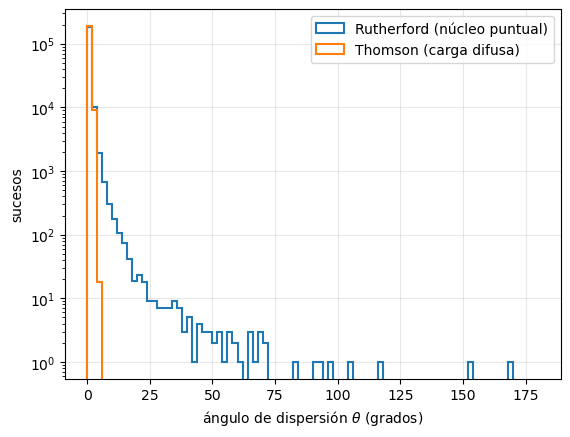

In [7]:
sim.rutherford(n=200000, E_MeV=5., Z_blanco=79);

### Descubrimiento del protón

Fue Ernest Rutherford quien, en 1917, identificó el protón. Al bombardear nitrógeno con partículas alfa observó que en la colisión aparecía una partícula más ligera que la alfa, con la misma carga positiva pero de masa mucho menor.

$$
{}^{14}\text{N} + \alpha \;\;\longrightarrow\;\; {}^{17}\text{O} + p
$$

En 1919, Rutherford concluyó que el núcleo del hidrógeno era un constituyente fundamental de la materia, presente en todos los núcleos atómicos. Así nació el concepto de protón como partícula elemental de carga positiva.

Permitió entender que todos los núcleos podían concebirse como combinaciones de protones (y más tarde neutrones, tras su descubrimiento en 1932).

Abrió la puerta a la idea de transmutaciones nucleares: un elemento podía convertirse en otro.

### Descubrimiento del neutrón

El modelo nuclear de Rutherford planteaba que los núcleos estaban compuestos únicamente de protones, pero la masa de los núcleos era mayor de lo que explicaba el número de protones. 

Por ejemplo, el núcleo de helio debía tener una masa de ~4 u, pero el modelo que se especulaba entonces —4 protones y 2 electrones en el núcleo— resultaba insostenible. Faltaba «algo» en el núcleo.

En 1930, Walther Bothe y Herbert Becker bombardearon berilio con partículas alfa y detectaron una radiación muy penetrante, más que los rayos gamma. Al principio se pensó que era radiación gamma de alta energía.

James Chadwick, en el laboratorio Cavendish (Cambridge), estudió con detalle esa radiación. Usó como blanco el berilio:

$$
\alpha + \, {}^9\text{Be} \;\longrightarrow\; \,{} ^{12}\text{C} + \, n
$$

Esa radiación impactaba en parafina (rica en protones), expulsando protones de la cera. Si fueran fotones gamma, la energía necesaria para expulsar protones sería enorme. Concluyó que la radiación no eran fotones, sino partículas neutras de masa comparable a la del protón. Chadwick llamó a estas partículas neutrones.

De esta forma los núcleos estaban formados por protones y neutrones (llamados ambos nucleones).

Explicó por qué los núcleos no explotaban electrostáticamente: los neutrones añadían masa sin carga, y es la fuerza fuerte la que liga los nucleones en el núcleo.

### Los cuatro magníficos

La Naturaleza está formada por átomos eléctricamente neutros formados por un núcleo masivo y electrones en capas. El núcleo está formado por protones (asociado con el número atómico $Z$) y neutrones (que conjuntamente dan el número másico $A$). Los electrones solo aportan del orden del $0.05\,\%$ de la masa del átomo.

El átomo está vacío: los núcleos tienen un tamaño del orden de 1-10 fm (fm = $10^{-15}$ m), mientras que el átomo tiene $10^{-10}$ m, esto es, entre ambos ¡hay un factor $10^5$!

Así pues en primera aproximación la Naturaleza está compuesta por:

$$
p, \;\; n, \;\; e
$$

Además del neutrino, $\nu$, que aparece en la desintegración $\beta$

Esto es, la materia del Universo está compuesta por 4 partículas "fundamentales":


$$
p, \;\; n, \;\; e, \;\; \nu
$$

Esta visión del mundo construido con $p, n, e$ duró solo unos meses: el neutrón se descubrió en febrero de 1932 y ¡ese mismo agosto se descubrió el positrón!

<div class="admonition tip">
<p class="admonition-title"><b>[>] Taller — El átomo está vacío</b></p>

El núcleo mide entre 1 y 10 fm; el átomo, $10^{-10}$ m.

1. ¿Qué fracción del **volumen** del átomo ocupa el núcleo?
2. Si el átomo fuese un campo de fútbol (100 m), ¿de qué tamaño sería el núcleo?
3. Y sin embargo el núcleo se lleva el 99.95 % de la masa. ¿Qué densidad tiene la
   materia nuclear? Compárala con la del agua.

</div>

<details>
<summary><b>Solución</b></summary>

1. El cociente de radios es $10^{-14}/10^{-10} = 10^{-4}$, luego el de
   volúmenes es $10^{-12}$. Una parte en un billón.
2. $100\ \mathrm{m} \times 10^{-4} = 1$ cm: una canica en el centro del campo. Todo lo
   demás son electrones y vacío.
3. $\rho \approx A m_p / (\frac{4}{3}\pi R^3)$ con $R \approx 1.2 A^{1/3}$ fm, que da
   $\rho \approx 2.3 \cdot 10^{17}$ kg/m³, unas $10^{14}$ veces la del agua.
   Una cucharadita pesaría mil millones de toneladas. Esa es, aproximadamente, la
   densidad de una estrella de neutrones.

</details>

### ¿Cómo se mira dentro de algo?

Rutherford descubrió el núcleo golpeándolo con partículas $\alpha$. Conviene pararse aquí
y preguntar:

* ¿Es el núcleo una esfera perfecta? ¿Tiene un borde definido?
* Si quisiéramos explorarlo **por dentro**, ¿cómo lo haríamos?
* ¿Por qué haría falta más energía para distinguir detalles más pequeños?

Las dos primeras preguntas se responden en la parte de Nuclear. La tercera es de esta
asignatura, y es la idea que se repite en todos los descubrimientos que siguen.

### Dispersión de electrones a alta energía

En la década de 1950 Hofstadter realizó en Stanford (California, EEUU), con el acelerador lineal Mark III, una serie de experimentos de dispersión de electrones de muy alta energía (100-500 MeV) sobre núcleos, y descubrió que los electrones exploraban la estructura nuclear al penetrar dentro del núcleo. Popularizó el fermi (fm = $10^{-15}$ m) como unidad de longitud y estableció que el núcleo no es una bola rígida.

| | 
|:--:| 
| <img src="./imgs/gen_hofstadter_diagram.png" width = 500 align="center"> |
| Diagrama de la dispersión de Hofstadter|



Lo que Hofstadter midió **no** coincidía con la dispersión de Mott, que supone un blanco
puntual: aparecía un factor de corrección, el **factor de forma**, que depende de cuánto
momento $q$ se le transfiere al blanco.

La razón de fondo es la relación de incertidumbre. Con una sonda que transfiere un momento
$q$ se resuelven detalles de tamaño

$$
d \sim \frac{\hbar}{q}
$$

Cuanta más energía, más fino el detalle: es un microscopio cuyo aumento se paga en GeV.
Un blanco **puntual** se ve igual a cualquier resolución; uno **extenso**, no.

El tratamiento cuantitativo del factor de forma, y lo que nos dice sobre el tamaño y la
forma del núcleo, lo veréis en la parte de Nuclear.

<div class="admonition tip">
<p class="admonition-title"><b>[>] Taller — Puntual o extenso</b></p>

El **factor de forma** $F(q^2)$ es lo que hay que añadir a la sección eficaz de Mott
—que supone el blanco puntual— para describir un blanco con tamaño. Es lo único que
separa *una carga en un punto* de *una carga repartida*.

1. ¿Cuánto vale $F(q^2)$ para un blanco **puntual**? ¿Qué aspecto tiene entonces la
   curva de $F$ frente a $q^2$?
2. Para un blanco **extenso**, $F$ cae al aumentar $q^2$. ¿Por qué? Piensa en las
   contribuciones de las distintas partes de la carga y en cómo se suman entre sí.
3. $F(q^2)$ es la transformada de Fourier de la distribución de carga. ¿Qué relación
   hay entonces entre *medir a $q^2$ grande* y *resolver detalles pequeños*?
4. Vuelve al primer Taller del tema. ¿Es el mismo argumento?

</div>


<details>
<summary><b>Solución</b></summary>

1. $F(q^2) = 1$ para todo $q^2$: la curva es plana y la sección eficaz coincide con la
   de Mott. Un objeto sin estructura se ve igual desde cualquier resolución.
2. Al aumentar $q^2$ la sonda distingue las distintas partes de la carga, cuyas
   contribuciones interfieren y se cancelan parcialmente. Cuanto más extenso es el
   objeto, más rápido cae $F$.
3. Es exactamente la relación de incertidumbre: resolución $\sim \hbar/q$. Medir a
   $q^2$ grande *es* mirar con una regla más fina.
4. Sí, es el mismo argumento con otro nombre. En 1911 se usó para descubrir que el
   átomo tiene núcleo; en los 50, para ver que el núcleo tiene tamaño; y en los 60, para
   ver que el nucleón tiene partones dentro. Una sola idea, tres descubrimientos.

</details>


### Three quarks for Muster Mark!

A finales de la década de 1960, usando electrones de más alta energía (los experimentos de dispersión inelástica profunda de SLAC-MIT, 1968-69), se pudo explorar el interior de los propios nucleones.

Así, los factores de forma mostraban patrones que coincidían con la posible existencia de partículas puntuales en el interior de los nucleones. R. Feynman los llamó partones.

Los conocemos como quarks. El término lo introdujo Murray Gell-Mann en 1964, cuando propuso su modelo para explicar la estructura de los hadrones (protones, neutrones, mesones). Tomó el nombre de la novela *Finnegans Wake* (1939) de James Joyce —un libro experimental y casi impenetrable, famoso por su lenguaje inventivo— del verso «Three quarks for Muster Mark!». Gell-Mann creía que los quarks eran solo una herramienta matemática para ordenar los hadrones descubiertos hasta la fecha.

De forma simultánea, George Zweig en el CERN también propuso un modelo de constituyentes internos para los hadrones.
Él los llamó «aces» (como los ases de una baraja). Él sí creía que eran reales.


Actualmente decimos que el protón y el neutrón están formados por quarks.

El quark _up_ ($u$) con carga $2|e|/3$  y el quark _down_ ($d$) con carga $-1|e|/3$. 

De tal forma que cada nucleón está compuesto por tres quarks ligados por la fuerza fuerte, y cuya carga total es entera:

$$
n = udd, \;\; p = uud
$$

| |
| :--| 
| <img src="./imgs/gen_proton_neutron.jpg" width = 400 align="center"> |
| Estructura del protón y del neutrón [Wikipedia]|



### Los cuatro y su compañía

Las cuatro partículas fundamentales son:

$$
u, \;\; d, \;\; e, \;\; \nu
$$

Pero la Naturaleza es más diversa:

* además de las partículas, existen las _antipartículas_, que tienen las cargas opuestas a las partículas; por ejemplo, el positrón, $e^+$

* existen partículas como otros _leptones_ (que se comportan como el electrón) y los _hadrones_ (que están formados por quarks) y que son inestables.

Clasificar y ordenar las partículas en la tabla de partículas del Modelo Estándar supuso un reto durante más de 40 años.


## Introducción al Modelo Estándar

El Modelo Estándar (SM) de la Física de Partículas es uno de los grandes logros de la Física (a pesar de su pobre nombre).

El Modelo clasifica todas las partículas elementales y establece las interacciones entre ellas. 

El *Particle Data Group* ([PDG](https://pdg.lbl.gov/)) es un grupo de trabajo que se encarga de recopilar y publicar toda la información relevante sobre física de partículas. Puedes consultar su página donde está *toda* la información.

En esta sección veremos brevemente cómo se clasifican las partículas y sus características principales.

### Las partículas son excitaciones de campos

La imagen de *corpúsculo* con la que abrimos el tema es útil, pero incompleta. En la teoría
que sostiene el Modelo Estándar el objeto fundamental no es la partícula, sino el **campo**:
una entidad definida en todo el espacio y en todo instante.

* A cada tipo de partícula le corresponde un campo: hay un campo del electrón, uno del
  fotón, uno para cada quark.

* Una **partícula** es una excitación de su campo, y su **masa** es la energía mínima de esa
  excitación. Todos los electrones del Universo son idénticos porque son excitaciones del
  mismo campo.

* Una **interacción** es el acoplo entre campos en un punto del espacio-tiempo: allí se
  destruyen unas excitaciones y se crean otras. Por eso en $n \to p + e + \bar{\nu}_e$
  no hace falta que hubiera un electrón *guardado* dentro del neutrón.

* El **alcance** de una fuerza lo fija la masa del campo que la media, alcance
  $\sim \hbar / (m c)$. El fotón no tiene masa y el electromagnetismo llega hasta el
  infinito; los bosones $W$ y $Z$ son pesados y la fuerza débil apenas alcanza $10^{-3}$ fm.

Leída así, la tabla del Modelo Estándar que viene a continuación es un catálogo de campos y
de sus acoplos. El desarrollo lo veremos en el tema de perspectiva teórica.

Hasta donde sabemos, la Naturaleza está compuesta de **12 fermiones** que forman la materia,
**12 bosones** que transmiten las fuerzas, y el **bosón de Higgs**, que les *otorga* las masas.

Ahora bien, toda la materia ordinaria del Universo está formada por solo 4 partículas: el
protón, el neutrón, el electrón y el neutrino; de ellas son estables el protón, el electrón y
el neutrino. El resto jugaron un papel en los primeros segundos del Universo y hoy se producen
sobre todo en los experimentos, donde se desintegran.

Junto a cada partícula está su **antipartícula**: misma masa, mismo espín y misma vida media,
cargas opuestas. Aparecen en pie de igualdad en las ecuaciones, y sin embargo el Universo actual
es casi solo materia (una de las preguntas abiertas del final del tema).

Hay **tres interacciones**:

  * la **electromagnética**, mediada por el fotón.

  * la **débil**, mediada por los bosones $W^\pm$ cuando cambia la carga eléctrica, y por el $Z$ cuando no.

  * la **fuerte**, mediada por los gluones. La responsable de la estabilidad de los núcleos es
    una fuerza fuerte *residual*, análoga al papel del electromagnetismo en la formación de moléculas.

Y la **masa** no es una propiedad intrínseca de la partícula: es consecuencia de su interacción
con el bosón de Higgs. Cuanta más masa, más intenso ese acoplo.

### El SM a simple vista

| |
|:--:|
|<img src="./imgs/intro_SM_table.png" width = 500 align="center">|
|Las partículas del Modelo Estándar|

  * Los **fermiones**, de espín $1/2$, forman la materia.

  * Los **bosones vectoriales**, de espín $1$, median las fuerzas fuerte, débil y electromagnética.

  * El **bosón escalar de Higgs**, de espín $0$, dota de masa a los fermiones y a los bosones vectoriales débiles.

### Fermiones

Los fermiones constituyen la materia, tienen espín $1/2$ y obedecen la ecuación de Dirac. Siguen
la estadística de Fermi-Dirac: no hay dos en un mismo estado, y de ahí que formen los bloques de
la materia.

Se dividen en:

  * **quarks**: si interaccionan fuertemente

  * **leptones**: si no interaccionan fuertemente

| fuerte | electromagnética | débil |
|---      |:--       | :--          |
| quarks | quarks y leptones cargados  | quarks y leptones |

Fue Dirac quien, a partir de su ecuación, propuso que cada partícula tiene su **antipartícula**,
descrita con un objeto nuevo, el *espinor*. Si $f$ es un fermión, $\bar{f}$ es su antifermión;
a los antileptones cargados los llamamos simplemente $e^+, \mu^+, \tau^+$.

#### Generaciones

Por alguna razón que desconocemos, existen tres generaciones o familias de partículas: las dos últimas son una copia, con más masa, de la primera. Sí sabemos que solo hay tres familias con neutrinos ligeros, gracias a la medida de la anchura de desintegración del bosón $Z$.

Decimos que los fermiones (tanto leptones como quarks) aparecen en **tres generaciones** o familias. 

$$
\begin{pmatrix} \nu_e \\ e \end{pmatrix}, \begin{pmatrix} \nu_\mu \\ \mu \end{pmatrix}, 
\begin{pmatrix} \nu_\tau \\ \tau \end{pmatrix} 
$$
$$
\begin{pmatrix} u \\ d \end{pmatrix}, \begin{pmatrix} c \\ s \end{pmatrix}, 
\begin{pmatrix} t \\ b \end{pmatrix} \\
$$

En cada generación, tanto leptones como quarks, se agrupan en **dupletes** con posiciones **arriba** y **abajo**.


Decimos que las tres generaciones de leptones se comportan con **universalidad** —de igual manera
frente a las interacciones— una vez tenida en cuenta la diferencia de masas.

Y decimos que las partículas tienen **sabor**, que es en realidad su identidad: el quark $s$ tiene
*extrañeza*, el $b$ *belleza*, el $\nu_e$ *sabor electrónico*. Que los estados de sabor y los de masa
no estén alineados da lugar a una física rica, la **física del sabor**, de la que las oscilaciones de
neutrinos son el ejemplo más conocido.

La siguiente tabla muestra los fermiones agrupados por familias, su carga eléctrica y las fuerzas que sienten: 

|   |  1   |  2   |  3  | Q (e) | fuerte | electromag. | débil | Higgs |
|-- | :--  | :--  | :-- | :--   | :--    |:--               |:--    | :-- |
|quarks   |  u | c  | t   | $\frac{2}{3}$   | sí | sí | sí | sí |
|         |  d   | s   | b   |  $-\frac{1}{3}$ | sí | sí|  sí | sí |
| leptones | $\nu_e$| $\nu_\mu$  | $\nu_\tau$   | 0  | no | no | sí | ? |
|         | $e$   | $\mu$  | $\tau$  | -1 | no | sí | sí | sí |


La carga eléctrica depende de su posición en el duplete. El fermión de arriba tiene una carga $+1$ comparada con la del de abajo.


Las masas de los fermiones:

| 1ª generación | 2ª generación | 3ª generación |
| :-- | :-- | :-- |
| $u$ (2 MeV) | $c$ (1.3 GeV) | $t$ (173 GeV) |
| $d$ (4.7 MeV) | $s$ (93 MeV) | $b$ (4.2 GeV) |
| $\nu_e$ ($<$ eV) | $\nu_\mu$ ($<$ eV) | $\nu_\tau$ ($<$ eV) |
| $e$ (511 keV) | $\mu$ (106 MeV) | $\tau$ (1.77 GeV) |

| |
|:--:|
|<img src="./imgs/intro_masas.png" width = 400 align="center">|
|Masas de los fermiones [MT1.1]|

El quark top es extremadamente pesado y el neutrino extraordinariamente ligero: más de $10^5$
veces más ligero que el electrón. No sabemos por qué los fermiones tienen este patrón de masas,
lo que equivale a decir que no sabemos por qué se acoplan al Higgs de forma tan dispar.

De las dos tablas se ve además que el neutrino es distinto: solo interacciona débilmente.

<div class="admonition tip">
<p class="admonition-title"><b>[>] Taller — El desierto de las masas</b></p>

La figura está en escala logarítmica, que es la única forma de que quepa.

1. ¿Cuántos órdenes de magnitud separan al neutrino del quark top?
2. Compáralo con algo cotidiano: ¿cuántos órdenes separan al electrón del protón?
3. Todas esas masas son **parámetros libres** del Modelo Estándar: la teoría no
   predice ninguna. ¿Te parece un problema estético o un problema físico?

</div>

<details>
<summary><b>Solución</b></summary>

1. $m_\nu < 1$ eV frente a $m_t \approx 173$ GeV $= 1.73 \cdot 10^{11}$ eV: **más de once
   órdenes de magnitud**. Y solo tenemos una cota superior para el neutrino, así que
   podrían ser muchos más.
2. $m_p/m_e \approx 1836$: apenas tres órdenes. Lo del neutrino y el top es de otra escala.
3. No hay respuesta consensuada, y esa es la gracia de la pregunta. El Modelo Estándar
   *funciona* con esos números metidos a mano —describe los datos con precisión
   extraordinaria—, pero sus 19 parámetros libres —26 contando las masas y las
   mezclas de los neutrinos— sin patrón aparente sugieren que hay una teoría más
   profunda debajo. El problema de la jerarquía de masas es una de las
   motivaciones centrales de la física de partículas actual.

</details>

### Leptones

Los leptones cargados $\mu, \tau$ son una copia con más masa del $e$.

Hasta la fecha hemos verificado que las interacciones conservan el **número leptónico**, $L$: el
número de leptones menos el de antileptones. Por ejemplo, en la desintegración $\beta$

$$
n \to p + e + \bar{\nu}_e
$$

$L = 0$ antes y después, porque $e$ aporta $L=+1$ y $\bar{\nu}_e$ aporta $L=-1$.

Por lo tanto **el neutrino, que es el leptón más ligero, es estable**.

Los leptones cargados se desintegran vía las interacciones débiles.

La siguiente tabla muestra sus vidas medias:

| $e$ | $\mu$ | $\tau$ |
| :--: | :--: | :--: |
| estable | $2.2 \times 10^{-6}$ s | $2.9 \times 10^{-13}$ s |

**El electrón es estable**, porque todas las interacciones conservan la carga eléctrica, y es el leptón cargado más ligero.

Un muón de 10 GeV recorre en promedio unos 60 km antes de desintegrarse ($\gamma \, c\tau \simeq 62$ km): por eso los muones atraviesan los detectores y llegan a la superficie desde la alta atmósfera.

El tauón, en cambio, se desintegra muy cerca del punto de producción: a 45 GeV recorre solo unos milímetros ($\gamma \, c\tau \simeq 2.2$ mm).


<div class="admonition tip">
<p class="admonition-title"><b>[>] Taller — ¿Cuánto vuela una partícula inestable?</b></p>

Comprueba tú los números del texto. Una partícula de vida media $\tau$ recorre, en
promedio, $d = \gamma \beta \, c \, \tau$ antes de desintegrarse.

1. Un **muón** de 10 GeV ($m = 105.7$ MeV, $\tau = 2.2\ \mu$s).
2. Un **tauón** de 45 GeV ($m = 1777$ MeV, $\tau = 2.9 \cdot 10^{-13}$ s).
3. ¿Qué consecuencia tiene esto para el diseño de un detector? ¿Cómo detectarías
   entonces un $\tau$?

</div>

<details>
<summary><b>Solución</b></summary>

1. $\gamma = 10/0.1057 \approx 95$, $\beta \approx 1$, $c\tau = 659$ m
   $\Rightarrow d \approx 62$ **km**. El muón atraviesa el detector entero sin
   desintegrarse; es la única partícula cargada que llega a las cámaras exteriores, y
   por eso se identifica precisamente por ser la que sale.
2. $\gamma = 45/1.777 \approx 25$, $c\tau = 87\ \mu$m $\Rightarrow d \approx 2.2$ mm.
3. Al $\tau$ no se le ve: se ven sus productos, saliendo de un **vértice desplazado**
   un par de milímetros del punto de colisión. *Medir* esos milímetros exige detectores
   de silicio con resolución de decenas de micras, y no los hubo hasta los años 80. El
   descubrimiento (Perl, 1975) llegó antes y por otra vía: sucesos $e\mu$ con energía
   perdida, en cuanto un colisionador $e^+e$ pasó del umbral de producción,
   $\sqrt{s} > 3.6$ GeV.

Tienes este cálculo escrito en código en el tema de [leptones](leptones.ipynb).

</details>

Existen tres neutrinos de sabor, $\nu_e, \nu_\mu, \nu_\tau$ asociados a sus parejas leptónicas $e, \mu, \tau$ respectivamente.

**El SM postulaba que no tienen masa**, pero gracias a los experimentos de oscilaciones de neutrinos sabemos que tienen masa.

Su masa se desconoce, pero es muy pequeña, $\lt 1$ eV, frente a los 511 keV del electrón.

**Los neutrinos** no tienen carga eléctrica, tienen una masa muy pequeña, son estables y solo interaccionan débilmente. ¡Son muy *cool*!

Son los leptones más peculiares del SM y que tengan masa es **la única prueba hasta el momento de que el SM es incompleto o incorrecto**.

Las características de los leptones y las peculiaridades de la desintegración débil y de los neutrinos las estudiaremos en el [tema de leptones](leptones.ipynb).

### Los quarks

Los quarks $(c, s)$ —encanto y extrañeza— y $(t, b)$ —top y belleza— son copias con más masa del
par $(u, d)$, arriba y abajo. Los quarks $u, d, s$ son ligeros y $c, b$ pesados. El top es incluso
más pesado que los bosones $W^\pm, Z$ y se desintegra antes de hadronizar, lo que hace que la física
de los hadrones con quarks ligeros y con quarks pesados sea distinta.

**Los quarks tienen carga fraccionaria**: $+2/3$ los de arriba y $-1/3$ los de abajo, en unidades de
$e$. No hay nada extraño en ello; que el electrón tenga carga negativa se lo debemos a B. Franklin,
y es solo una convención.

**Los quarks no son libres**: solo aparecen en partículas compuestas, los **hadrones**. Es el
**confinamiento**. Si fueran libres los habríamos detectado sin dificultad, porque un campo magnético
curvaría sus trayectorias según su carga.

Todavía no tenemos una explicación exacta del confinamiento de los quarks, pero la teoría que rige las interacciones fuertes, la **cromodinámica cuántica**, QCD, permite una explicación.

Los quarks aparecen con tres cargas fuertes o de **color**, que se denominan: **rojo, verde y azul**, $r, g, b$. Y por supuesto no tiene nada que ver con los colores habituales. 

Esto es, un mismo quark existe en tres colores, por ejemplo el quark belleza, $b$, puede ser rojo, verde o azul. Esto quiere decir que en realidad no tenemos 6 quarks sino 18. Decimos que *cada quark de sabor se presenta en tres colores* (no solo hay simetría en física, a veces, también hay poesía).

Para cada color existe también su anti-color, esto es anti-rojo, anti-verde o anti-azul, que viene asociado a los anti-quarks.

Sin embargo, la QCD exige que los únicos hadrones reales sean **neutros al color**, digamos que son *descoloridos* o *blancos*, de forma similar al hecho de que los átomos son eléctricamente neutros.

Estudiaremos los quarks, los hadrones y el color en el [tema de quarks y hadrones](quarks_hadrons.ipynb).

Solo hay dos posibilidades de combinación de quarks para que los hadrones sean *incoloros*, o bien mediante una combinación de tres quarks (o antiquarks), cada uno con un color, lo que llamamos barión (o antibarión), o un mesón, formado por un quark y un antiquark con colores complementarios (por ejemplo, rojo y anti-rojo)

Los **hadrones** se clasifican en:

  * **bariones**, formados por tres quarks.
  
  * **mesones**, formados por un par quark y antiquark.

| |
| :--| 
| <img src="./imgs/intro_hadrons.png" width = 300 align="center"> |
| Imagen esquemática de un mesón y un barión|

Con estas dos posibilidades, la carga eléctrica de los hadrones es entera.

En los últimos años se han observado además hadrones exóticos —tetraquarks y pentaquarks—, igualmente neutros al color.


El protón y el neutrón son bariones: el protón está formado por los quarks de valencia $(uud)$, de
carga $+e$, y el neutrón por $(udd)$, de carga nula.

También hemos comprobado que se conserva el **número bariónico**, $B$ —bariones menos antibariones—.
Los mesones tienen $B = 0$, así que en vez de contar quarks contamos bariones. En la desintegración
$\beta$, $B = 1$ a ambos lados. Y como **el protón es el barión más ligero, es estable**.

La $\beta$ es posible energéticamente porque el $n$ (939 MeV) es algo más pesado que el $p$
(938.3 MeV). De esa pequeña diferencia proviene que la vida media del neutrón sea de unos 15 minutos
($\tau = 878.4$ s).

Muy diferente sería la Naturaleza si el neutrino no fuese el leptón más ligero y pudiera
desintegrarse, o si el protón tuviera más masa que el neutrón.

El resto de hadrones —mesones o bariones— y los leptones cargados $\mu, \tau$ se desintegran. La
vida media depende de dos cosas:

  * el **tipo de interacción** que gobierna la desintegración: fuerte (vía gluones), electromagnética
    (vía fotón) o débil (vía $W^\pm$).

  * el **espacio fásico** disponible: a mayor diferencia de masas entre la partícula madre y las hijas,
    más espacio fásico.

| |
|:--|
| <img src="./imgs/intro_lifetimes.png" width = 400 align="center">|
| Vida media de algunas partículas dependiendo del tipo de desintegración [MT1.1]|

Las partículas que se desintegran débilmente son las de vida media *mayor*.

<div class="admonition tip">
<p class="admonition-title"><b>[>] Taller — Por qué el neutrón vive tanto</b></p>

En la figura las partículas se agrupan por el tipo de interacción que gobierna su
desintegración, y las vidas medias abarcan más de veinte órdenes de magnitud.

1. Ordena de mayor a menor vida media: fuerte, electromagnética, débil. ¿Por qué ese orden?
2. El neutrón vive **15 minutos** y el muón **2.2 microsegundos**. Las dos son
   desintegraciones débiles. ¿De dónde salen los ocho órdenes de magnitud de diferencia?
3. ¿Qué esperarías si una partícula pudiera desintegrarse por más de una interacción a la vez?

</div>

<details>
<summary><b>Solución</b></summary>

1. Débil $\gg$ electromagnética $\gg$ fuerte, porque la vida media va como el inverso
   del cuadrado del acoplo. Con las intensidades relativas de la tabla ($1$, $10^{-3}$,
   $10^{-8}$) salen los rangos típicos: $10^{-23}$ s las fuertes, $10^{-16}$ s las
   electromagnéticas, y de $10^{-13}$ s para arriba las débiles.
2. **Espacio fásico.** No es el acoplo, que es el mismo: es la energía disponible.
   $Q(n \to p + e + \bar{\nu}_e) = 0.78$ MeV, ridícula, porque $n$ y $p$ tienen casi la misma masa;
   $Q(\mu \to e + \bar{\nu}_e + \nu_\mu) \approx 105$ MeV, prácticamente toda la masa del muón.
   La regla de Sargent dice $\Gamma \propto E_0^5$, donde $E_0$ es la energía **total**
   del punto final del espectro. Para el muón $E_0 \simeq 105.7$ MeV; para el neutrón
   $E_0 = Q + m_e = 1.293$ MeV, y aquí no vale tomar $E_0 \simeq Q$, porque
   $m_e = 0.511$ MeV es comparable a $Q$. Con eso $(105.7/1.293)^5 \approx 3.6\cdot10^9$,
   que el factor $1 + 3g_A^2 \approx 5.8$ de la corriente axial del neutrón baja hasta
   $\sim 6\cdot10^8$: ya del orden de la diferencia observada,
   $\tau_n/\tau_\mu \approx 4\cdot10^8$.
3. Ganaría siempre la más intensa de las permitidas. Por eso una partícula solo se
   desintegra débilmente si las otras dos le están prohibidas por alguna ley de
   conservación — y ahí está la clave de por qué las vidas medias largas son
   *informativas*: te dicen qué está prohibido.

</details>

### Los números aditivos

Hay cantidades que son las dos cosas a la vez: todos los observadores miden el mismo valor, y ese valor no cambia en la interacción. Toman valores discretos, en unidades de la carga del electrón o como números enteros, y se suman entre partículas. (Los quarks son la excepción: su carga es fraccionaria, $\pm 1/3$ y $\pm 2/3$.)

Sabemos que las interacciones conservan:

* la carga eléctrica

$$
\sum_i^{iniciales} q_i = \sum_j^{finales} q_j
$$

donde $q_i$ es la carga de cada partícula.

Y también:

* el número leptónico, $L$

* el número bariónico, $B$

El número leptónico y el bariónico son leyes fenomenológicas: sabemos que se conservan porque lo hemos comprobado experimentalmente.

Lo que nos permite saber si una interacción se realiza o no en la Naturaleza.

**Ayuda:** números cuánticos de las partículas que vamos a usar.

| | $q$ | $B$ | $L$ |
|:--|:--:|:--:|:--:|
| $p$, $n$ (bariones) | $+1$, $\; 0$ | $+1$ | $0$ |
| $\bar{p}$ (antibarión) | $-1$ | $-1$ | $0$ |
| $\pi^+$, $\pi^0$ (mesones) | $+1$, $\; 0$ | $0$ | $0$ |
| $e$, $\mu$ (leptones) | $-1$ | $0$ | $+1$ |
| $\bar{\nu}_e$ (antileptón) | $0$ | $0$ | $-1$ |
| $\gamma$ (fotón) | $0$ | $0$ | $0$ |

Las antipartículas tienen $q$, $B$ y $L$ opuestos.

**Ojo:** ser neutro no implica ser la propia antipartícula. El $\pi^0$ y el $\gamma$ sí lo son,
pero el neutrino no ($\nu_e \neq \bar{\nu}_e$) y el neutrón tampoco: el **antineutrón** existe
(descubierto en 1956, un año después del antiprotón) y se distingue del $n$ por tener $B = -1$
y el momento magnético de signo opuesto.

<div class="admonition tip">
<p class="admonition-title"><b>[>] Taller — ¿Puede ocurrir en la Naturaleza?</b></p>

Con lo que sabes de conservación de la **carga** $q$, del **número leptónico** $L$ y
del **número bariónico** $B$ —y con la tabla de ayuda anterior—, decide cuáles de estos
procesos están permitidos y cuáles no:

| | proceso |
|:--|:--|
| a | $p \to \pi^+ + \pi^0$ |
| b | $n \to p + e + \bar{\nu}_e$ |
| c | $\mu \to e + \gamma$ |
| d | $p + p \to p + p + p + \bar{p}$ |

Para el que esté permitido pero necesite energía, ¿cuánta hace falta como mínimo?

</div>

<details>
<summary><b>Solución</b></summary>

* **a) Prohibido.** $q$ se conserva ($+1 \to +1$), pero $B$ no: $1 \to 0$. El protón es
  el barión más ligero y por eso es estable, hasta donde hemos podido medir.
* **b) Permitido.** $q: 0 \to 1-1+0$. $B: 1 \to 1$. $L: 0 \to +1-1 = 0$. Es la desintegración $\beta$.
* **c) Ojo.** Conserva $q$, $B$ y el número leptónico **total**. Y sin embargo **no se ha
  observado nunca**: falta un ingrediente, la conservación del número leptónico *de sabor*
  (electrónico, muónico, tauónico) por separado. El límite experimental es feroz,
  $BR < 3 \cdot 10^{-13}$ al 90% de nivel de confianza. Volveremos a ello en el tema de leptones.
* **d) Permitido.** $B: 2 \to 3 - 1 = 2$. Es la reacción con la que se descubrió el
  antiprotón. Hace falta crear $2 m_p$ de masa; en blanco fijo el umbral resulta
  ser $T_{lab} = 6 m_p \approx 5.6$ GeV, mucho más que $2m_p$, porque el centro de masas
  se lleva energía cinética.

</details>

### Los mediadores de las fuerzas

Describimos las interacciones como el intercambio de un **mediador** o portador de la fuerza entre las
partículas. Cada portador interviene según la carga —eléctrica, de color— de los fermiones con los que
interacciona.

Los portadores son **bosones vectoriales** (espín 1): el fotón y los gluones, sin masa, obedecen
ecuaciones del tipo de Maxwell; los bosones débiles $W^\pm, Z$, masivos, la ecuación de Proca.

| fuerza            | intensidad | bosón            | Q (e) | masa (GeV) |
| :--               | :--        | :--              | :--   | :--     |
| fuerte            | 1          | $g$ (gluón)      | 0     | 0       |
| electromagnetismo | $10^{-3}$  | $\gamma$ (fotón) | 0     | 0       |
| débil             | $10^{-8}$  | $W^{\pm}$        | $\pm1$  | 80.4 |
|                   |            | $Z$              | 0     | 91.2    |
| gravedad          | $10^{-38}$ | (gravitón)       | 0     | 0       |

Fue **Yukawa** quien, para explicar la fuerza que mantiene unidos los nucleones en el núcleo, propuso
un potencial que decae exponencialmente a partir de un radio típico (el fm), y con él una partícula
mediadora masiva de unos 100 MeV: el **pión**, descubierto en 1947 con una masa de 140 MeV.

Es la relación entre alcance y masa del mediador que ya hemos visto, alcance $\sim \hbar/(mc)$. El fotón
no tiene masa y el electromagnetismo tiene alcance *infinito*; los $W^\pm, Z$ pesan 80 y 91 GeV y la
interacción débil resulta prácticamente *puntual*. A esa escala de masas la llamamos **escala
electrodébil**, $\mathcal{O}(100)$ GeV, que corresponde a $10^{-18}$ m.

<div class="admonition tip">
<p class="admonition-title"><b>[>] Taller — El alcance según Yukawa</b></p>

Yukawa relacionó el alcance de una fuerza con la masa de su mediador:
$R \approx \hbar/(mc)$, es decir, $R \approx \hbar c / (m c^2)$.

Con $\hbar c = 197$ MeV fm, calcula el alcance de:

1. el **pión** ($m = 140$ MeV) — compáralo con el tamaño del núcleo;
2. el **$W$** ($m = 80.4$ GeV);
3. el **fotón** ($m = 0$).

Y al revés: si mides que una fuerza tiene alcance $10^{-18}$ m, ¿qué masa tiene su mediador?

</div>

<details>
<summary><b>Solución</b></summary>

1. $R = 197 / 140 \approx 1.4$ fm. Justo el tamaño de un núcleo: por eso Yukawa acertó,
   y por eso el pión se buscó con esa masa. (Se encontró en 1947, con 140 MeV.)
2. $R = 197 / 80400 \approx 2.5 \cdot 10^{-3}$ fm $= 2.5 \cdot 10^{-18}$ m. A las escalas
   de un núcleo, esto es *cero*: la interacción débil parece puntual, y de ahí la
   teoría de Fermi de corrientes de contacto.
3. $R \to \infty$. El alcance infinito del electromagnetismo y de la gravedad es la
   huella de que sus mediadores no tienen masa.

Al revés: $m c^2 = 197\ \mathrm{MeV\,fm} / 10^{-3}\ \mathrm{fm} \approx 200$ GeV, del orden
de la escala electrodébil. Medir un alcance es medir una masa.

</details>

Los bosones $W^\pm$ están cargados eléctricamente y transportan esa carga en las interacciones que
median; por eso a sus interacciones se las llama, por abuso del lenguaje, **corrientes cargadas** (CC).
Las del $Z^0$ son las **corrientes neutras** (NC): como el fotón, el $Z$ no transmite carga eléctrica.

Existen **8 gluones**, eléctricamente neutros y sin masa, pero **con color**: intercambian el color de
los quarks (un gluón puede convertir un quark rojo en azul y a la vez uno azul en rojo). Como
transportan color, los gluones interaccionan entre sí, y en ello está la clave del alcance limitado de
la interacción fuerte.

#### Propiedades de las fuerzas

Adelantamos algunas propiedades de las fuerzas que se discutirán en los temas siguientes.

**Las interacciones electromagnética y fuerte conservan el sabor y la paridad**, y la fuerte conserva
además las **cargas de color**: si los quarks iniciales son rojo y azul, entre los finales hay rojo y
azul. En este sentido son interacciones *clásicas*.

La **paridad** es la inversión ${\bf x} \to - {\bf x}$, el cambio de signo de las coordenadas
espaciales; la **conjugación de carga** cambia todas las cargas de la partícula. Las estudiaremos en el
tema de interacciones débiles, donde son protagonistas.


Por el contrario, las interacciones débiles son *peculiares* y *sorprendentes*, porque violan
    
   * la **paridad**, (las cargadas de forma máxima).
   
   Lo que es una característica esencial de la interacción débil y una de las piezas angulares del Modelo Estándar.
   
   * la inversión conjunta de **carga y paridad**, CP. 
   
   Se viola de forma mínima y solo en corrientes cargadas en hadrones, (no sabemos hoy en día si también se viola en leptones). Aunque esta violación es muy relevante, sin embargo no tiene un carácter fundamental en la teoría, sino que aparece como una posibilidad al existir tres generaciones. Tampoco sabemos por qué se produce este nivel de violación CP, que matemáticamente se traduce en el valor de una fase compleja en una matriz unitaria (ver el [tema de quarks y hadrones](quarks_hadrons.ipynb)).

Además, **las corrientes cargadas cambian el sabor, pero las neutras lo conservan**.

Por ejemplo, la interacción débil neutra entre un neutrino y un leptón cargado iniciales da lugar a una dispersión con el mismo neutrino y leptón cargado en el estado final.

Luego, la interacción más peculiar de todas es con diferencia *la interacción débil cargada*, la que media la desintegración $\beta$ del neutrón.


<div class="admonition tip">
<p class="admonition-title"><b>[>] Taller — ¿Se viola CP en los leptones?</b></p>

El texto afirma que **no sabemos** si la violación CP ocurre también en el sector
leptónico. Esa frase tiene fecha de caducidad: compruébala.

1. ¿Qué experimentos están midiendo hoy la fase de violación CP en oscilaciones de
   neutrinos? Busca **T2K** y **NOvA**.
2. ¿Qué sensibilidad esperan **DUNE** e **Hyper-Kamiokande**, y para cuándo?
3. ¿Por qué importa tanto? Relaciónalo con la pregunta "¿por qué el Universo está hecho
   de materia?" que aparece al final del tema.

Fuente de referencia: la reseña *Neutrino Masses, Mixing, and Oscillations* del
[PDG](https://pdg.lbl.gov/), que se actualiza cada año.

</div>

<details>
<summary><b>Cómo abordarlo</b></summary>

No te doy la respuesta a 1 y 2 a propósito: el estado de estas medidas cambia con
cada campaña de datos, y cualquier número que escriba aquí estará obsoleto cuando lo
leas. Ve al PDG y a las páginas de las colaboraciones, y **anota la fecha** de lo que
encuentres.

Sobre la 3: el Universo tiene materia y no antimateria, y para explicarlo hacen falta
las tres condiciones de Sájarov, una de las cuales es precisamente la violación de CP.
La violación CP que conocemos, la del sector de quarks (matriz CKM), es
**varios órdenes de magnitud demasiado pequeña** para dar cuenta de la asimetría
observada. De ahí el interés en buscarla en los leptones: la leptogénesis es hoy uno
de los mecanismos candidatos.

</details>

### El bosón de Higgs

Ahora sabemos, o entendemos, que las partículas de forma primigenia no tienen masa, y ésta no es una propiedad intrínseca suya, sino que aparece por la interacción de cada tipo de fermión con el bosón de Higgs. 

El bosón de Higgs es un **escalar**, su espín es $0$, y obedece a la ecuación de Klein-Gordon.

Y como vemos juega un papel crucial en el SM:

   * **dota de masas a las partículas**.
   
   * dota de masas **a los bosones vectoriales débiles $W^\pm, Z$**.
   
Aunque la masa aparece como consecuencia de la interacción con el Higgs, el modelo no predice sin embargo qué masa tienen los fermiones, ni qué masa tiene el Higgs. Lo que hace que las masas sean parámetros libres del modelo.

El Higgs, además, presenta interacciones consigo mismo, con los bosones vectoriales débiles y con los fermiones, lo que da lugar a la predicción de una física muy rica y compleja que es motivo de estudio actual en el LHC y lo será con seguridad en futuros aceleradores.

Estudiaremos las características del SM y del bosón de Higgs en el [tema del Modelo Estándar](sm.ipynb).

## Un repaso a la historia

### Hitos principales

La siguiente figura presenta algunos de los hitos principales en Física de Partículas, experimental, teórica y de detectores.

| |
| :--: | 
| <img src="./imgs/intro_particles_history.jpg" width = 800 align="center">|
| Hitos de la Historia de Física de Partículas|

A vuelo de pájaro:

* Durante las primeras décadas del siglo XX se descubrieron los componentes del núcleo (*los componentes de la materia ordinaria: protón, neutrón, electrón, neutrino*).

* En las décadas siguientes se descubrieron nuevos hadrones y leptones que se desintegraban (*¿Quién ha ordenado esto?, ¿por qué este bestiario de nuevas partículas?*)

* A partir de mediados de los 60, con el modelo de quarks (1964) y el estudio de la estructura de los nucleones (SLAC, 1968-69), se establece la existencia de los quarks (*¡orden al fin!*)

* En las décadas de los 80-90 se confirma el Modelo Estándar (*todo encaja, pero falta una pieza, el bosón de Higgs*)

* En 2012 se descubre el bosón de Higgs (*El modelo está completo, pero no es suficiente...*)

### Detectores, Experimentos, Teoría

Enumeramos ahora cómo las tres ramas —detectores, experimental y teoría— se complementan, y cómo han influido unas en otras a lo largo de la historia de la Física de Partículas

Nuevos detectores permiten nuevos descubrimientos:

  * Las emulsiones fotográficas permitieron la observación de partículas, $\mu, \pi$

  * Los centelleadores y los reactores nucleares, el descubrimiento del neutrino $\nu_e$.
    
  * Los detectores de silicio, la determinación de partículas de vida corta, $\tau, B$

Los experimentos revelan una Naturaleza inesperada:

  * La violación de Paridad y CP en corrientes débiles.
  
  * Tres familias de leptones y de quarks.
  
  * La matriz de mezcla, CKM, que rige las corrientes cargadas entre los quarks.
  
  * Oscilaciones de neutrinos.

La construcción de la teoría guía a los descubrimientos:

  * Pauli postula la existencia del neutrino.

  * Gell-Mann propone el modelo de quarks y la ordenación del 'zoo' de hadrones.
    
  * La unificación electro-débil predice las corrientes neutras de neutrinos.
  
  * La rotura espontánea de simetría postula la existencia del bosón de Higgs.

Algunos de los avances experimentales más relevantes son:
    
  * El descubrimiento del positrón (antimateria)
  
  * El descubrimiento de partículas inesperadas: $\mu, ...$
  
  * El descubrimiento del neutrino y sus propiedades.
  
  * La violación de Paridad y de CP en corrientes débiles
  
  * La existencia de los quarks y los gluones
  
  * La existencia de las corrientes neutras y la verificación del SM
  
  * La verificación de la matriz de mezclas CKM, que rige la física del sabor de los hadrones.
  
  * El descubrimiento de oscilaciones de neutrinos
  
  * El descubrimiento del bosón de Higgs

Los avances teóricos más importantes:

  * La ecuación de Dirac y la existencia de la antimateria
  
  * El potencial de Yukawa
  
  * La teoría de Fermi de interacciones entre corrientes.
  
  * Los diagramas de Feynman (QED)
  
  * El modelo de quarks de Gell-Mann y Zweig.
  
  * La unificación electro-débil, el Modelo Estándar (SM) de Glashow, Salam y Weinberg.
  
  * El mecanismo de Brout, Englert y Higgs.

### Preguntas sin respuesta

Aún quedan por resolver bastantes preguntas de las que no conocemos la respuesta:

* ¿Se conserva el número bariónico? ¿Se desintegra el protón?

* ¿Se conserva el número leptónico? ¿Es el neutrino su propia anti-partícula?

* ¿Son los quarks y leptones elementales? ¿Y el bosón de Higgs?

* ¿Por qué hay 3 generaciones?

* ¿Hay un patrón que explique las masas de los fermiones?

* ¿Por qué hay tanta disparidad de masas entre el neutrino y el resto de fermiones? ¿Se acopla el neutrino al bosón de Higgs?

* ¿Por qué el Universo está formado por materia y no por anti-materia? ¿Qué pasó con la anti-materia del Universo?

* ¿Qué forma la materia oscura?

Si tenemos en cuenta que la materia del Universo que conocemos o decimos conocer supone un 5% del total, nos damos cuenta de que queda aún mucho camino por recorrer...

<div class="admonition tip">
<p class="admonition-title"><b>[>] Taller — Adopta una pregunta abierta</b></p>

Cierra el tema eligiendo **una** de las preguntas de la lista anterior y averigua qué
se está haciendo hoy para responderla:

1. ¿Qué experimento (o experimentos) la atacan ahora mismo? ¿Dónde están?
2. ¿Cuál es el mejor límite o la mejor medida publicada, y de qué año?
3. ¿Qué haría falta —en energía, en estadística o en técnica— para dar el siguiente paso?

Escribe media página. La usaremos en clase.

Puntos de partida: las reseñas del [PDG](https://pdg.lbl.gov/) y las páginas de las
propias colaboraciones.

</div>

<details>
<summary><b>Sugerencias por si te atascas</b></summary>

* **¿Se desintegra el protón?** Super-Kamiokande y, en el futuro, Hyper-Kamiokande y DUNE.
  Busca el límite actual en $\tau/BR$ y compáralo con la edad del Universo ($1.4\cdot10^{10}$ años).
* **¿Es el neutrino su propia antipartícula?** Experimentos de doble desintegración beta
  sin neutrinos: KamLAND-Zen, GERDA/LEGEND, CUORE, NEXT (con participación española y del IGFAE).
* **¿Qué es la materia oscura?** Detección directa (XENON, LZ, PandaX, ANAIS en Canfranc),
  indirecta y producción en el LHC. Fíjate en cómo se compara la sensibilidad de las tres.
* **¿Por qué hay materia y no antimateria?** Enlaza con el Taller sobre violación CP en leptones.

En todos los casos: **anota la fecha** del dato que encuentres. Estas preguntas están vivas.

</details>

### Nomenclatura:

| nombres          | definición |
| :---          | :--- |
| *partícula*  | corpúsculo que puede sentir las fuerzas electromagnética, débil o fuerte |
| *antipartícula* | partícula con las cargas y números cuánticos (excepto masa y espín) opuestos a la partícula|
| *fermión*  | partícula de espín 1/2 |
| *leptón*  (ligero) | fermión que no siente la fuerza fuerte |
| *quark*    | fermión que siente la fuerza fuerte |
| *bosón*    | partícula de espín entero |
| *bosón gauge*| bosón portador de la fuerza, $W, Z, \gamma, g$; tienen espín 1 (vectoriales) |
| *hadrón*  (fuerte) | partícula compuesta que siente la fuerza fuerte|
| *barión*   | hadrón compuesto de tres quarks |
| *mesón*   (mediano)| hadrón compuesto de quark y antiquark |



[Para esta sección ver MT1.1 y AB1.8, AB1.9]



## Bibliografía

 * [AB] A. Bettini, *Introduction to Elementary Particle Physics*, Cambridge U. Press. Tema 1

 * [MT] M. Thomson, *Modern Particle Physics*, Cambridge U. Press. Tema 1
    
 * [PDG](https://pdg.lbl.gov/) Particle Data Group.

## Créditos de las imágenes

Las figuras que genera el código de estos apuntes (`fnyp/`) son de elaboración propia.
Para el resto:

**Cedidas por sus autores**

Los diagramas `gen_interaction_diagram`, `gen_plab`, `gen_pcm`, `gen_jlab`, `gen_jcm`,
`gen_xsec`, `gen_xsec_omega` y `gen_xsec_espesor` son obra de
**M. Caamaño** (USC), que autoriza su uso en estos apuntes.

**De Wikimedia Commons**

| Imagen | Fichero original | Autoría | Licencia |
|:--|:--|:--|:--|
| `Dr_Fabiola_Gianotti.jpg` | [CDS 2116825](https://cds.cern.ch/record/2116825) | Maximilien Brice (CERN) | CC BY 4.0 |
| `Prof_Mark_Thomson.jpg` | [Prof Mark Thomson.jpg](https://commons.wikimedia.org/wiki/File:Prof_Mark_Thomson.jpg) | Orso3553 | CC BY-SA 4.0 |
| `gen_Co60_decay.png` | [Cobalt-60 Decay Scheme.svg](https://commons.wikimedia.org/wiki/File:Cobalt-60_Decay_Scheme.svg) | Inductiveload | Dominio público |
| `gen_proton_neutron.jpg` | [Quark structure neutron.svg](https://commons.wikimedia.org/wiki/File:Quark_structure_neutron.svg) + [Quark structure proton.svg](https://commons.wikimedia.org/wiki/File:Quark_structure_proton.svg) | Harp; Arpad Horvath | CC BY-SA 2.5 |
| `gen_tabla_periodica.png` | [Periodic table large-es-updated-2018.svg](https://commons.wikimedia.org/wiki/File:Periodic_table_large-es-updated-2018.svg) | 2012rc; trad. al español de The Photographer | CC BY 3.0 |

Tres de ellas están **modificadas**: la foto de M. Thomson se ha recortado y reescalado,
`gen_proton_neutron.jpg` combina dos ficheros y les añade rótulos en español, y
`gen_tabla_periodica.png` es un recorte de la tabla. Al ser las originales **CC BY-SA**
(salvo la tabla y el diagrama del $^{60}$Co), esas versiones derivadas heredan la misma
licencia.

**Con fuente indicada en el pie**

**[MT]** y **[AB]**, los libros de la bibliografía; **[PDG]**, **[ATLAS]**, **[OPAL]**, **[LHCb]** y **[SK]**, esas colaboraciones;
**[CERN]**, el laboratorio.

> **Pendiente.** De las 34 imágenes del tema, 13 tienen ya procedencia y licencia
> establecidas. De las 21 restantes, nueve tienen fuente conocida pero licencia sin
> comprobar ([MT] ×2, [PDG], [ATLAS] ×2, [CERN], [SK], [OPAL], [LHCb]) y `gen_xsecdif.png` está marcada como *[Wiki]* sin
> que haya sido posible localizar el original. Conviene cerrarlas antes de distribuir el
> Book más allá del aula.
